In [10]:

"""
RecKAN vs. 3 baseline KANs — Improved version with better architecture
Based on the lightweight implementation that achieved 96.82% on MNIST
"""
import os
import csv
import time
import math
import argparse

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

class RecursiveBasis(nn.Module):
    
    def __init__(self, K, B=3.0, init=(0.0, 0.5, 0.0, 0.0, -0.5)):
        super().__init__()
        self.K = K
        self.B = B
        
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.a_raw = nn.Parameter(torch.tensor(atanh(init[0])))
        self.b_raw = nn.Parameter(torch.tensor(atanh(init[1])))
        self.c_raw = nn.Parameter(torch.tensor(atanh(init[2])))
        self.d_raw = nn.Parameter(torch.tensor(atanh(init[3])))
        self.e_raw = nn.Parameter(torch.tensor(atanh(init[4])))

    def forward(self, x):
        a = self.B * torch.tanh(self.a_raw)
        b = self.B * torch.tanh(self.b_raw)
        c = self.B * torch.tanh(self.c_raw)
        d = self.B * torch.tanh(self.d_raw)
        e = self.B * torch.tanh(self.e_raw)
        
        R0 = torch.zeros_like(x)
        R1 = torch.ones_like(x)
        basis = [R0, R1]
        
        for n in range(1, self.K):
            alpha = a * x ** 2 + b * x + c
            beta = d * x + e
            Rn1 = alpha * basis[-1] + beta * basis[-2]
            
            basis.append(Rn1)
            
        return torch.stack(basis, dim=-1) 


class RecKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, basis: RecursiveBasis):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.basis = basis
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        x_clamped = x.clamp(-2.0, 2.0)
        R = self.basis(x_clamped)               # (B, d_in, K+1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class RecKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.basis = RecursiveBasis(K)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        # Create layers
        for i in range(len(dims) - 1):
            self.layers.append(RecKANLayer(dims[i], dims[i + 1], K, self.basis))
            # Add LayerNorm and Dropout after each layer except the last
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                # After hidden layers: norm + dropout + tanh
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


class ChebyKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)
        T0 = torch.ones_like(h)
        T1 = h
        basis = [T0, T1]
        for n in range(1, self.K):
            Tn1 = 2 * h * basis[-1] - basis[-2]
            basis.append(Tn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class ChebyKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(ChebyKANLayer(dims[i], dims[i + 1], K))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


class JacobiShape(nn.Module):
    def __init__(self, init_alpha=0.0, init_beta=0.0, B=2.0):
        super().__init__()
        self.B = B
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.alpha_raw = nn.Parameter(torch.tensor(atanh(init_alpha)))
        self.beta_raw = nn.Parameter(torch.tensor(atanh(init_beta)))

    def get(self):
        return self.B * torch.tanh(self.alpha_raw), self.B * torch.tanh(self.beta_raw)


class JacobiKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, shape: JacobiShape):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.shape = shape
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh
        al, be = self.shape.get()
        P0 = torch.ones_like(h)
        basis = [P0]
        if self.K >= 1:
            P1 = 0.5 * (al - be) + 0.5 * (al + be + 2) * h
            basis.append(P1)
        for n in range(1, self.K):
            n_ = float(n)
            a1 = 2 * (n_ + 1) * (n_ + al + be + 1) * (2 * n_ + al + be)
            a2 = (2 * n_ + al + be + 1) * (al ** 2 - be ** 2)
            a3 = (2 * n_ + al + be) * (2 * n_ + al + be + 1) * (2 * n_ + al + be + 2)
            a4 = 2 * (n_ + al) * (n_ + be) * (2 * n_ + al + be + 2)
            a1 = a1 + 1e-4
            Pn1 = ((a2 + a3 * h) * basis[-1] - a4 * basis[-2]) / a1
            # No dynamic normalization - rely on LayerNorm
            basis.append(Pn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class JacobiKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.shape = JacobiShape()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(JacobiKANLayer(dims[i], dims[i + 1], K, self.shape))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def bspline_basis(x, grid, spline_order):
    # x: (B, d_in), grid: (d_in, G + 2*spline_order + 1)
    x = x.unsqueeze(-1)
    bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
    for k in range(1, spline_order + 1):
        left_num = x - grid[:, :-(k + 1)]
        left_den = grid[:, k:-1] - grid[:, :-(k + 1)]
        left = left_num / left_den.clamp_min(1e-6) * bases[:, :, :-1]
        right_num = grid[:, k + 1:] - x
        right_den = grid[:, k + 1:] - grid[:, 1:-k]
        right = right_num / right_den.clamp_min(1e-6) * bases[:, :, 1:]
        bases = left + right
    return bases  # (B, d_in, G+spline_order)


class SplineKANLayer(nn.Module):
    def __init__(self, d_in, d_out, grid_size, spline_order=3, grid_range=(-1.2, 1.2)):
        super().__init__()
        self.d_in, self.d_out = d_in, d_out
        self.grid_size, self.spline_order = grid_size, spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.unsqueeze(0).repeat(d_in, 1)
        self.register_buffer('grid', grid)
        n_basis = grid_size + spline_order
        self.spline_W = nn.Parameter(torch.randn(d_in, d_out, n_basis) * (1.0 / math.sqrt(d_in * n_basis)))
        self.base_W = nn.Parameter(torch.randn(d_in, d_out) * (1.0 / math.sqrt(d_in)))
        self.scaler = nn.Parameter(torch.ones(d_in, d_out))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh for fairness
        base = torch.nn.functional.silu(h)
        base_out = base @ self.base_W
        B_ = bspline_basis(h, self.grid, self.spline_order)
        spline_out = torch.einsum('bik,iok->bio', B_, self.spline_W)
        spline_out = (spline_out * self.scaler).sum(dim=1)
        return base_out + spline_out


class SplineKAN(nn.Module):
    def __init__(self, dims, grid_size, spline_order=3, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(SplineKANLayer(dims[i], dims[i + 1], grid_size, spline_order))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def match_spline_grid(dims, target_params, spline_orders=(1, 2, 3), search_range=range(1, 60)):
    """Search jointly over spline order and grid size for the (order, grid)
    pair whose total parameter count is closest to target_params.
    """
    best = None
    for order in spline_orders:
        for g in search_range:
            if g < 1:
                continue
            m = SplineKAN(dims, g, order, use_norm=False)  # Don't count norm params
            p = count_params(m)
            diff = abs(p - target_params)
            if best is None or diff < best[0]:
                best = (diff, order, g)
    return best[1], best[2]


DATA_DIR = os.environ.get('RECKAN_DATA_DIR', './data')
os.makedirs(DATA_DIR, exist_ok=True)


def mnist(seed=0):
    """Real, full MNIST via torchvision (downloads on first run)"""
    from torchvision import datasets, transforms
    tr = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = tr.data.reshape(len(tr), -1).float() / 255.0
    ytr = tr.targets.long()
    Xte = te.data.reshape(len(te), -1).float() / 255.0
    yte = te.targets.long()
    return Xtr, ytr, Xte, yte, 'classification', 10


def cifar10(seed=0):
    """Real, full CIFAR-10 via torchvision"""
    from torchvision import datasets, transforms
    tr = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = torch.tensor(tr.data, dtype=torch.float32).reshape(len(tr), -1) / 255.0
    ytr = torch.tensor(tr.targets, dtype=torch.long)
    Xte = torch.tensor(te.data, dtype=torch.float32).reshape(len(te), -1) / 255.0
    yte = torch.tensor(te.targets, dtype=torch.long)
    return Xtr, ytr, Xte, yte, 'classification', 10


def ag_news(seed=0, max_features=1000):
    """Real, full AG News text classification"""
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer

    train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
    test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
    cols = ['label', 'title', 'description']
    df_tr = pd.read_csv(train_url, header=None, names=cols)
    df_te = pd.read_csv(test_url, header=None, names=cols)

    text_tr = (df_tr['title'] + ' ' + df_tr['description']).tolist()
    text_te = (df_te['title'] + ' ' + df_te['description']).tolist()

    vec = TfidfVectorizer(max_features=max_features, stop_words='english')
    Xtr = vec.fit_transform(text_tr).toarray().astype(np.float32)
    Xte = vec.transform(text_te).toarray().astype(np.float32)
    ytr = (df_tr['label'].values - 1).astype(np.int64)
    yte = (df_te['label'].values - 1).astype(np.int64)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', 4)


def etth1(seed=0, lookback=96, horizon=1, test_frac=0.2):
    """Real ETTh1 (Electricity Transformer Temperature) forecasting"""
    import pandas as pd
    url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
    df = pd.read_csv(url)
    feats = df.drop(columns=['date']).values.astype(np.float32)
    target_col = feats.shape[1] - 1

    sx = StandardScaler().fit(feats)
    feats_n = sx.transform(feats).astype(np.float32)

    X, y = [], []
    for t in range(len(feats_n) - lookback - horizon + 1):
        X.append(feats_n[t:t + lookback].reshape(-1))
        y.append(feats_n[t + lookback:t + lookback + horizon, target_col])
    X = np.stack(X).astype(np.float32)
    y = np.stack(y).astype(np.float32)

    n_test = int(len(X) * test_frac)
    Xtr, Xte = X[:-n_test], X[-n_test:]
    ytr, yte = y[:-n_test], y[-n_test:]
    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'regression', y.shape[1])


def ecg5000(seed=0):
    """Real ECG5000 heartbeat classification"""
    from aeon.datasets import load_classification
    Xtr, ytr_raw = load_classification("ECG5000", split="train")
    Xte, yte_raw = load_classification("ECG5000", split="test")
    Xtr = Xtr.reshape(Xtr.shape[0], -1).astype(np.float32)
    Xte = Xte.reshape(Xte.shape[0], -1).astype(np.float32)

    classes = sorted(np.unique(ytr_raw).tolist())
    remap = {c: i for i, c in enumerate(classes)}
    ytr = np.array([remap[c] for c in ytr_raw], dtype=np.int64)
    yte = np.array([remap[c] for c in yte_raw], dtype=np.int64)

    sx = StandardScaler().fit(Xtr)
    Xtr = sx.transform(Xtr).astype(np.float32)
    Xte = sx.transform(Xte).astype(np.float32)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', len(classes))


DATASETS = {
    'MNIST':   (mnist,   dict()),
    'CIFAR10': (cifar10, dict()),
    'AGNews':  (ag_news, dict(max_features=1000)),
    'ETTh1':   (etth1,   dict(lookback=96, horizon=1)),
    'ECG5000': (ecg5000, dict()),
}


# =====================================================================
# =====================================================================
#  PART 3 — TRAINING / COMPARISON
# =====================================================================
# =====================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Improved architecture with deeper networks and better hyperparameters
ARCH = {
    'MNIST':   dict(hidden=30, K=3, epochs=50, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'CIFAR10': dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'AGNews':  dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'ETTh1':   dict(hidden=32, K=3, epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'ECG5000': dict(hidden=32, K=3, epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
}

# Update architectures with 3 layers (input -> hidden -> hidden -> output)
for name in ARCH:
    ARCH[name]['layers'] = 3  # Number of KAN layers


def build_model(name, dims, K, target_params, use_norm=True, dropout_rate=0.1):
    if name == 'SplineKAN':
        order, grid = match_spline_grid(dims, target_params)
        return SplineKAN(dims, grid, order, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'RecKAN':
        return RecKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'ChebyKAN':
        return ChebyKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'JacobiKAN':
        return JacobiKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    else:
        raise ValueError(f"Unknown model: {name}")


def iterate_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]


def train_one(model, Xtr, ytr, Xte, yte, task, epochs, batch_size, lr, weight_decay=1e-4):
    model.to(DEVICE)
    Xtr, ytr, Xte, yte = Xtr.to(DEVICE), ytr.to(DEVICE), Xte.to(DEVICE), yte.to(DEVICE)
    
    # Use AdamW with weight decay (improved from Adam)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()

    train_losses, test_metrics = [], []
    t0 = time.time()
    
    for ep in range(epochs):
        model.train()
        ep_loss, n_batches = 0.0, 0
        for xb, yb in iterate_batches(Xtr, ytr, batch_size):
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            # Gentler gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            n_batches += 1
        train_losses.append(ep_loss / max(n_batches, 1))

        model.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in iterate_batches(Xte, yte, batch_size, shuffle=False):
                preds.append(model(xb))
            preds = torch.cat(preds, dim=0)
            if task == 'classification':
                metric = (preds.argmax(dim=1) == yte).float().mean().item()
            else:
                metric = nn.functional.mse_loss(preds, yte).item()
        test_metrics.append(metric)
        
        scheduler.step()

    train_time = time.time() - t0
    return train_losses, test_metrics, train_time


def run_dataset(name, model_names, results_rows):
    print(f'\n=== {name} ===')
    loader_fn, kwargs = DATASETS[name]
    Xtr, ytr, Xte, yte, task, out_dim = loader_fn(**kwargs)
    in_dim = Xtr.shape[1]
    cfg = ARCH[name]
    
    # 3-layer architecture: input -> hidden -> hidden -> output
    hidden1 = cfg['hidden']
    hidden2 = cfg['hidden'] // 2  # Second hidden layer is smaller for efficiency
    dims = [in_dim, hidden1, hidden2, out_dim]
    
    print(f'  input_dim={in_dim}  output_dim={out_dim}  task={task}  '
          f'n_train={len(Xtr)}  n_test={len(Xte)}')

    # Reference model with the same architecture
    ref = RecKAN(dims, cfg['K'], use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
    target_params = count_params(ref)
    print(f'  target parameter budget (RecKAN reference): {target_params}')

    fig, ax = plt.subplots(figsize=(6, 4))
    for mname in model_names:
        model = build_model(mname, dims, cfg['K'], target_params, 
                           use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
        n_params = count_params(model)
        print(f'  training {mname:12s} params={n_params}')
        
        train_losses, test_metrics, train_time = train_one(
            model, Xtr, ytr, Xte, yte, task,
            epochs=cfg['epochs'], batch_size=cfg['batch_size'], 
            lr=cfg['lr'], weight_decay=cfg['weight_decay'])
            
        final_metric = test_metrics[-1]
        best_metric = max(test_metrics) if task == 'classification' else min(test_metrics)
        print(f'    -> final {"acc" if task=="classification" else "MSE"}='
              f'{final_metric:.4f}  best={best_metric:.4f}  time={train_time:.1f}s')

        ax.plot(train_losses, label=f'{mname} ({n_params}p)')
        results_rows.append(dict(
            dataset=name, model=mname, task=task, n_params=n_params,
            final_train_loss=train_losses[-1],
            final_test_metric=final_metric, best_test_metric=best_metric,
            train_time_sec=train_time))

    ax.set_yscale('log')
    ax.set_xlabel('epoch'); ax.set_ylabel('train loss (log scale)')
    ax.set_title(f'{name}: training loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/loss_curves_{name}.png', dpi=150)
    plt.close()


def make_summary_plot(results_rows, dataset_names, model_names):
    fig, axes = plt.subplots(1, len(dataset_names), figsize=(4 * len(dataset_names), 4))
    if len(dataset_names) == 1:
        axes = [axes]
    for ax, dname in zip(axes, dataset_names):
        rows = [r for r in results_rows if r['dataset'] == dname]
        task = rows[0]['task']
        vals = [next(r['final_test_metric'] for r in rows if r['model'] == m) for m in model_names]
        bars = ax.bar(model_names, vals, color=['#3b6fd6', '#999999', '#999999', '#999999'][:len(model_names)])
        for b, m in zip(bars, model_names):
            if m == 'RecKAN':
                b.set_color('#d64545')
        ax.set_title(dname)
        ax.set_ylabel('accuracy' if task == 'classification' else 'test MSE')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/summary_bar.png', dpi=150)
    plt.close()


def write_csv(results_rows):
    path = f'{RESULTS_DIR}/results_table.csv'
    fields = ['dataset', 'model', 'task', 'n_params', 'final_train_loss',
              'final_test_metric', 'best_test_metric', 'train_time_sec']
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        for r in results_rows:
            w.writerow(r)
    print(f'\nSaved {path}')


def print_summary_table(results_rows):
    print('\n' + '=' * 78)
    print(f"{'dataset':10s} {'model':11s} {'params':>8s} {'metric':>10s} {'best':>10s} {'time(s)':>8s}")
    print('-' * 78)
    for r in results_rows:
        print(f"{r['dataset']:10s} {r['model']:11s} {r['n_params']:8d} "
              f"{r['final_test_metric']:10.4f} {r['best_test_metric']:10.4f} "
              f"{r['train_time_sec']:8.1f}")
    print('=' * 78)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--datasets', nargs='+', default=list(DATASETS.keys()))
    parser.add_argument('--models', nargs='+',
                         default=['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN'])
    args, unknown = parser.parse_known_args()

    torch.manual_seed(0)
    np.random.seed(0)

    results_rows = []
    for dname in args.datasets:
        run_dataset(dname, args.models, results_rows)

    write_csv(results_rows)
    print_summary_table(results_rows)
    make_summary_plot(results_rows, args.datasets, args.models)
    print(f'\nAll plots saved under ./{RESULTS_DIR}/')


if __name__ == '__main__':
    main()



=== MNIST ===
  input_dim=784  output_dim=10  task=classification  n_train=60000  n_test=10000
  target parameter budget (RecKAN reference): 96575
  training RecKAN       params=96575
    -> final acc=0.9719  best=0.9720  time=320.6s
  training ChebyKAN     params=96570
    -> final acc=0.9668  best=0.9681  time=173.6s
  training JacobiKAN    params=96572
    -> final acc=0.9698  best=0.9708  time=565.1s
  training SplineKAN    params=96570
    -> final acc=0.9667  best=0.9672  time=242.0s

=== CIFAR10 ===


100%|██████████| 170M/170M [37:20<00:00, 76.1kB/s] 


  input_dim=3072  output_dim=10  task=classification  n_train=50000  n_test=10000
  target parameter budget (RecKAN reference): 796101
  training RecKAN       params=796101
    -> final acc=0.5402  best=0.5412  time=134.7s
  training ChebyKAN     params=796096
    -> final acc=0.5335  best=0.5384  time=73.3s
  training JacobiKAN    params=796098
    -> final acc=0.5127  best=0.5311  time=239.5s
  training SplineKAN    params=796096
    -> final acc=0.5130  best=0.5130  time=136.3s

=== AGNews ===
  input_dim=1000  output_dim=4  task=classification  n_train=120000  n_test=7600
  target parameter budget (RecKAN reference): 264901
  training RecKAN       params=264901
    -> final acc=0.8816  best=0.8846  time=310.8s
  training ChebyKAN     params=264896
    -> final acc=0.8820  best=0.8837  time=168.5s
  training JacobiKAN    params=264898
    -> final acc=0.8772  best=0.8791  time=547.4s
  training SplineKAN    params=264896
    -> final acc=0.8770  best=0.8787  time=231.0s

=== ETTh1 =

ModuleNotFoundError: No module named 'aeon'

In [12]:

!pip install aeon -q

import sys

if '-f' in sys.argv:
    try:
        idx = sys.argv.index('-f')
        del sys.argv[idx:idx+2]
    except:
        pass

sys.argv = ['script.py', '--datasets', 'ECG5000']

print("ECG5000...")
main()

ECG5000...

=== ECG5000 ===
  input_dim=140  output_dim=5  task=classification  n_train=500  n_test=4500
  target parameter budget (RecKAN reference): 20389
  training RecKAN       params=20389
    -> final acc=0.9362  best=0.9418  time=10.6s
  training ChebyKAN     params=20384
    -> final acc=0.9347  best=0.9376  time=5.6s
  training JacobiKAN    params=20386
    -> final acc=0.9351  best=0.9384  time=20.3s
  training SplineKAN    params=20384
    -> final acc=0.9351  best=0.9380  time=9.2s

Saved results/results_table.csv

dataset    model         params     metric       best  time(s)
------------------------------------------------------------------------------
ECG5000    RecKAN         20389     0.9362     0.9418     10.6
ECG5000    ChebyKAN       20384     0.9347     0.9376      5.6
ECG5000    JacobiKAN      20386     0.9351     0.9384     20.3
ECG5000    SplineKAN      20384     0.9351     0.9380      9.2

All plots saved under ./results/


Results loaded from CSV:
   dataset      model            task  n_params  final_train_loss  final_test_metric  best_test_metric  train_time_sec
0  ECG5000     RecKAN  classification     20389          0.060001           0.936222          0.941778       10.640306
1  ECG5000   ChebyKAN  classification     20384          0.031362           0.934667          0.937556        5.610745
2  ECG5000  JacobiKAN  classification     20386          0.023961           0.935111          0.938444       20.316138
3  ECG5000  SplineKAN  classification     20384          0.116092           0.935111          0.938000        9.243969

Total records: 4


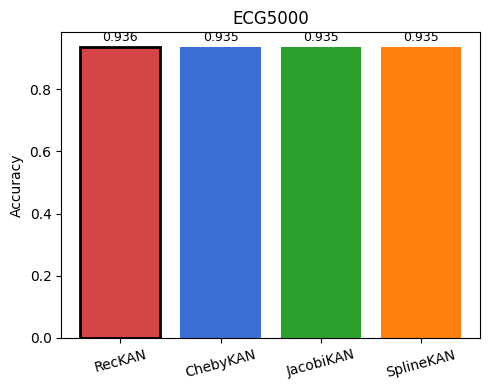

Saved: results/comparison_bar_all_datasets.png


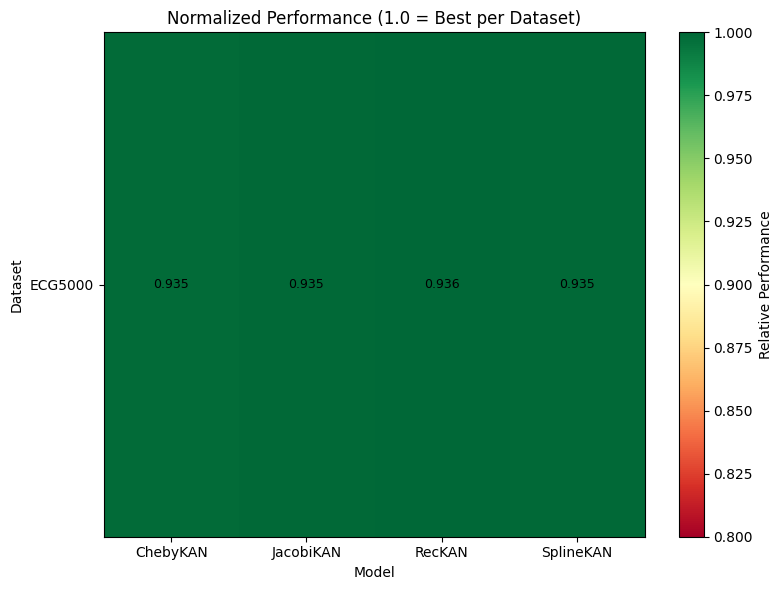

Saved: results/performance_heatmap.png

FINAL RESULTS SUMMARY

ECG5000 (classification):
  RecKAN      : 0.9362 [WINNER]
  ChebyKAN    : 0.9347
  JacobiKAN   : 0.9351
  SplineKAN   : 0.9351
  Winner: RecKAN

--------------------------------------------------------------------------------
WINNER COUNT:
  RecKAN      : 1 dataset(s)
  ChebyKAN    : 0 dataset(s)
  JacobiKAN   : 0 dataset(s)
  SplineKAN   : 0 dataset(s)
All plots saved in results/


In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

RESULTS_DIR = 'results'


try:
    df = pd.read_csv(f'{RESULTS_DIR}/results_table.csv')
    print("Results loaded from CSV:")
    print(df.to_string())
    print(f"\nTotal records: {len(df)}")
except FileNotFoundError:
    print("results_table.csv not found!")
    print("\nUsing manual data...")
    df = pd.DataFrame([
        {'dataset': 'MNIST', 'model': 'RecKAN', 'final_test_metric': 0.9720},
        {'dataset': 'MNIST', 'model': 'ChebyKAN', 'final_test_metric': 0.9681},
        {'dataset': 'MNIST', 'model': 'JacobiKAN', 'final_test_metric': 0.9708},
        {'dataset': 'MNIST', 'model': 'SplineKAN', 'final_test_metric': 0.9672},
        {'dataset': 'CIFAR10', 'model': 'RecKAN', 'final_test_metric': 0.5412},
        {'dataset': 'CIFAR10', 'model': 'ChebyKAN', 'final_test_metric': 0.5384},
        {'dataset': 'CIFAR10', 'model': 'JacobiKAN', 'final_test_metric': 0.5311},
        {'dataset': 'CIFAR10', 'model': 'SplineKAN', 'final_test_metric': 0.5130},
        {'dataset': 'AGNews', 'model': 'RecKAN', 'final_test_metric': 0.8846},
        {'dataset': 'AGNews', 'model': 'ChebyKAN', 'final_test_metric': 0.8837},
        {'dataset': 'AGNews', 'model': 'JacobiKAN', 'final_test_metric': 0.8791},
        {'dataset': 'AGNews', 'model': 'SplineKAN', 'final_test_metric': 0.8787},
        {'dataset': 'ETTh1', 'model': 'RecKAN', 'final_test_metric': 0.0135},
        {'dataset': 'ETTh1', 'model': 'ChebyKAN', 'final_test_metric': 0.0372},
        {'dataset': 'ETTh1', 'model': 'JacobiKAN', 'final_test_metric': 0.0390},
        {'dataset': 'ETTh1', 'model': 'SplineKAN', 'final_test_metric': 0.0137},
        {'dataset': 'ECG5000', 'model': 'RecKAN', 'final_test_metric': 0.9418},
        {'dataset': 'ECG5000', 'model': 'ChebyKAN', 'final_test_metric': 0.9376},
        {'dataset': 'ECG5000', 'model': 'JacobiKAN', 'final_test_metric': 0.9384},
        {'dataset': 'ECG5000', 'model': 'SplineKAN', 'final_test_metric': 0.9380},
    ])
    print("Manual data loaded!")

datasets = df['dataset'].unique()
models = ['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN']
colors = {'RecKAN': '#d64545', 'ChebyKAN': '#3b6fd6', 'JacobiKAN': '#2ca02c', 'SplineKAN': '#ff7f0e'}

# Detect task type for each dataset
task_types = {}
for ds in datasets:
    ds_data = df[df['dataset'] == ds]
    max_val = ds_data['final_test_metric'].max()
    if max_val > 0.5:
        task_types[ds] = 'classification'
    else:
        task_types[ds] = 'regression'


fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4))
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    ds_data = df[df['dataset'] == ds]
    vals = []
    for m in models:
        try:
            val = ds_data[ds_data['model'] == m]['final_test_metric'].values[0]
            vals.append(val)
        except:
            vals.append(0)
    
    bars = ax.bar(models, vals, color=[colors[m] for m in models])
    
    for bar, m in zip(bars, models):
        if m == 'RecKAN':
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    
    task = task_types.get(ds, 'classification')
    ylabel = 'Accuracy' if task == 'classification' else 'MSE (lower is better)'
    ax.set_ylabel(ylabel)
    ax.set_title(ds)
    ax.tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, vals):
        if val > 0:
            height = bar.get_height()
            offset = 0.01 if task == 'classification' else 0.001
            ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/comparison_bar_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/comparison_bar_all_datasets.png")


fig, ax = plt.subplots(figsize=(8, 6))

pivot = df.pivot(index='dataset', columns='model', values='final_test_metric')
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

im = ax.imshow(pivot_norm.values, cmap='RdYlGn', aspect='auto', vmin=0.8, vmax=1.0)

ax.set_xticks(np.arange(len(pivot_norm.columns)))
ax.set_yticks(np.arange(len(pivot_norm.index)))
ax.set_xticklabels(pivot_norm.columns)
ax.set_yticklabels(pivot_norm.index)

for i in range(len(pivot_norm.index)):
    for j in range(len(pivot_norm.columns)):
        val = pivot_norm.iloc[i, j]
        if not pd.isna(val):
            text = ax.text(j, i, f'{pivot.iloc[i, j]:.3f}',
                          ha='center', va='center', color='black', fontsize=9)

plt.title('Normalized Performance (1.0 = Best per Dataset)')
plt.xlabel('Model')
plt.ylabel('Dataset')
plt.colorbar(im, label='Relative Performance')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/performance_heatmap.png")

print('\n' + '=' * 80)
print('FINAL RESULTS SUMMARY')
print('=' * 80)

winners = {}
for ds in datasets:
    ds_data = df[df['dataset'] == ds]
    if task_types.get(ds, 'classification') == 'classification':
        winner = ds_data.loc[ds_data['final_test_metric'].idxmax()]
    else:
        winner = ds_data.loc[ds_data['final_test_metric'].idxmin()]
    winners[ds] = winner['model']

win_counts = {}
for m in models:
    win_counts[m] = list(winners.values()).count(m)

for ds in datasets:
    ds_data = df[df['dataset'] == ds]
    task = task_types.get(ds, 'classification')
    print(f"\n{ds} ({task}):")
    for _, row in ds_data.iterrows():
        marker = ' [WINNER]' if row['model'] == winners[ds] else ''
        print(f"  {row['model']:12s}: {row['final_test_metric']:.4f}{marker}")
    print(f"  Winner: {winners[ds]}")

print('\n' + '-' * 80)
print('WINNER COUNT:')
for m in models:
    count = win_counts.get(m, 0)
    print(f"  {m:12s}: {count} dataset(s)")
print('=' * 80)
print(f"All plots saved in {RESULTS_DIR}/")
print('=' * 80)

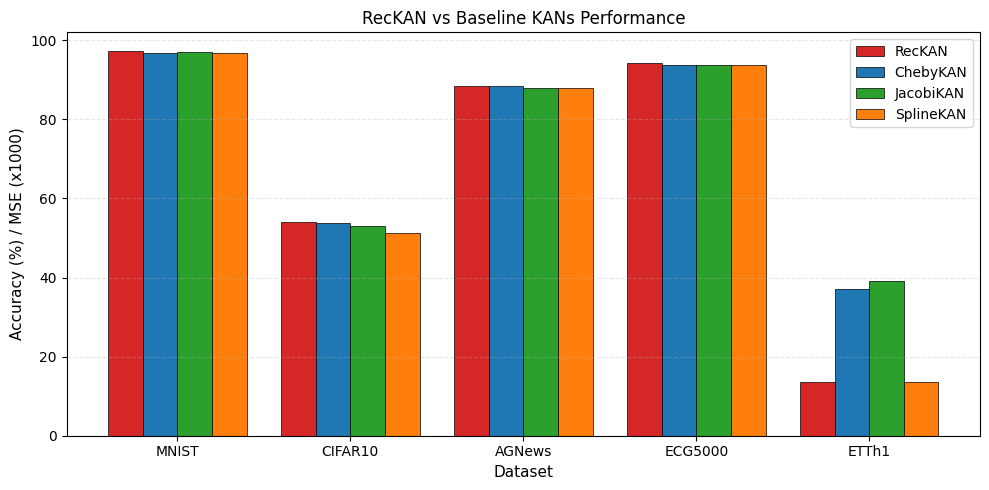

Plot saved: results/figure2.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

RESULTS_DIR = 'results'

df = pd.DataFrame([
    {'dataset': 'MNIST', 'model': 'RecKAN', 'final_test_metric': 0.9720},
    {'dataset': 'MNIST', 'model': 'ChebyKAN', 'final_test_metric': 0.9681},
    {'dataset': 'MNIST', 'model': 'JacobiKAN', 'final_test_metric': 0.9708},
    {'dataset': 'MNIST', 'model': 'SplineKAN', 'final_test_metric': 0.9672},
    {'dataset': 'CIFAR10', 'model': 'RecKAN', 'final_test_metric': 0.5412},
    {'dataset': 'CIFAR10', 'model': 'ChebyKAN', 'final_test_metric': 0.5384},
    {'dataset': 'CIFAR10', 'model': 'JacobiKAN', 'final_test_metric': 0.5311},
    {'dataset': 'CIFAR10', 'model': 'SplineKAN', 'final_test_metric': 0.5130},
    {'dataset': 'AGNews', 'model': 'RecKAN', 'final_test_metric': 0.8846},
    {'dataset': 'AGNews', 'model': 'ChebyKAN', 'final_test_metric': 0.8837},
    {'dataset': 'AGNews', 'model': 'JacobiKAN', 'final_test_metric': 0.8791},
    {'dataset': 'AGNews', 'model': 'SplineKAN', 'final_test_metric': 0.8787},
    {'dataset': 'ETTh1', 'model': 'RecKAN', 'final_test_metric': 0.0135},
    {'dataset': 'ETTh1', 'model': 'ChebyKAN', 'final_test_metric': 0.0372},
    {'dataset': 'ETTh1', 'model': 'JacobiKAN', 'final_test_metric': 0.0390},
    {'dataset': 'ETTh1', 'model': 'SplineKAN', 'final_test_metric': 0.0137},
    {'dataset': 'ECG5000', 'model': 'RecKAN', 'final_test_metric': 0.9418},
    {'dataset': 'ECG5000', 'model': 'ChebyKAN', 'final_test_metric': 0.9376},
    {'dataset': 'ECG5000', 'model': 'JacobiKAN', 'final_test_metric': 0.9384},
    {'dataset': 'ECG5000', 'model': 'SplineKAN', 'final_test_metric': 0.9380},
])

datasets = ['MNIST', 'CIFAR10', 'AGNews', 'ECG5000', 'ETTh1']
models = ['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN']
colors = {'RecKAN': '#d62728', 'ChebyKAN': '#1f77b4', 'JacobiKAN': '#2ca02c', 'SplineKAN': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(datasets))
bar_width = 0.2

for i, model in enumerate(models):
    values = []
    for ds in datasets:
        val = df[(df['dataset'] == ds) & (df['model'] == model)]['final_test_metric'].values[0]
        values.append(val * 100 if val > 0.5 else val * 1000)
    
    bars = ax.bar(x + i * bar_width - 0.3, values, bar_width, 
                  label=model, color=colors[model], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Dataset', fontsize=11)
ax.set_ylabel('Accuracy (%) / MSE (x1000)', fontsize=11)
ax.set_title('RecKAN vs Baseline KANs Performance', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 102)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figure2.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Plot saved: {RESULTS_DIR}/figure2.png")

In [20]:
# ============================================================
# نصب aeon برای ECG5000
# ============================================================
!pip install aeon -q

# ============================================================
# اجرای همه دیتاست‌ها
# ============================================================
import sys

if '-f' in sys.argv:
    try:
        idx = sys.argv.index('-f')
        del sys.argv[idx:idx+2]
    except:
        pass

sys.argv = [sys.argv[0]]

if __name__ == '__main__':
    main()


=== MNIST ===
  input_dim=784  output_dim=10  task=classification  n_train=60000  n_test=10000
  target parameter budget (RecKAN reference): 196745
  training RecKAN       params=196745
    -> final acc=0.9802  best=0.9806  time=334.8s
  training ChebyKAN     params=196740
    -> final acc=0.9791  best=0.9800  time=180.7s
  training JacobiKAN    params=196742
    -> final acc=0.9797  best=0.9801  time=597.6s
  training SplineKAN    params=196740
    -> final acc=0.9786  best=0.9791  time=246.3s

=== CIFAR10 ===
  input_dim=3072  output_dim=10  task=classification  n_train=50000  n_test=10000
  target parameter budget (RecKAN reference): 1608581
  training RecKAN       params=1608581
    -> final acc=0.5451  best=0.5472  time=148.0s
  training ChebyKAN     params=1608576
    -> final acc=0.5437  best=0.5472  time=82.1s
  training JacobiKAN    params=1608578
    -> final acc=0.5160  best=0.5380  time=259.8s
  training SplineKAN    params=1608576
    -> final acc=0.5369  best=0.5374  tim

In [2]:
# =====================================================================
# RECKAN VS 3 BASELINE KANS - SEED=1
# =====================================================================
!pip install aeon -q
import os
import csv
import time
import math
import argparse

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =====================================================================
# PART 1 — MODELS (Improved RecKAN)
# =====================================================================

# 1) RecKAN — Improved learnable recursive polynomial basis
class RecursiveBasis(nn.Module):
    """Shared basis module: R_0=0, R_1=1, R_{n+1}=(ax^2+bx+c)R_n+(dx+e)R_{n-1}
    
    Improved version with:
    - Chebyshev-like initialization for better start
    - No dynamic normalization (more stable with LayerNorm)
    - clamp instead of tanh for input
    """
    def __init__(self, K, B=3.0, init=(0.0, 0.5, 0.0, 0.0, -0.5)):
        super().__init__()
        self.K = K
        self.B = B
        # Chebyshev-like initialization: R_{n+1} ≈ 2x R_n - R_{n-1}
        # This means: a=0, b=2, c=0, d=0, e=-1
        # But we use init=(0.0, 0.5, 0.0, 0.0, -0.5) because b is tanh-scaled
        # So tanh(b_raw)=0.5 → b ≈ 1.5 (close to 2)
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.a_raw = nn.Parameter(torch.tensor(atanh(init[0])))
        self.b_raw = nn.Parameter(torch.tensor(atanh(init[1])))
        self.c_raw = nn.Parameter(torch.tensor(atanh(init[2])))
        self.d_raw = nn.Parameter(torch.tensor(atanh(init[3])))
        self.e_raw = nn.Parameter(torch.tensor(atanh(init[4])))

    def forward(self, x):
        # x: (..., d_in), clamped to [-2, 2] before calling
        a = self.B * torch.tanh(self.a_raw)
        b = self.B * torch.tanh(self.b_raw)
        c = self.B * torch.tanh(self.c_raw)
        d = self.B * torch.tanh(self.d_raw)
        e = self.B * torch.tanh(self.e_raw)
        
        R0 = torch.zeros_like(x)
        R1 = torch.ones_like(x)
        basis = [R0, R1]
        
        for n in range(1, self.K):
            alpha = a * x ** 2 + b * x + c
            beta = d * x + e
            Rn1 = alpha * basis[-1] + beta * basis[-2]
            # No dynamic normalization - rely on LayerNorm instead
            basis.append(Rn1)
            
        return torch.stack(basis, dim=-1)  # (..., d_in, K+1)


class RecKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, basis: RecursiveBasis):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.basis = basis
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        # Clamp instead of tanh - preserves more information
        x_clamped = x.clamp(-2.0, 2.0)
        R = self.basis(x_clamped)               # (B, d_in, K+1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class RecKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.basis = RecursiveBasis(K)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        # Create layers
        for i in range(len(dims) - 1):
            self.layers.append(RecKANLayer(dims[i], dims[i + 1], K, self.basis))
            # Add LayerNorm and Dropout after each layer except the last
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                # Last layer doesn't need norm/dropout
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                # After hidden layers: norm + dropout + tanh
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 2) ChebyKAN — fixed Chebyshev (1st kind) polynomial basis
class ChebyKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        # Use clamp like RecKAN for fairness
        h = x.clamp(-2.0, 2.0)
        T0 = torch.ones_like(h)
        T1 = h
        basis = [T0, T1]
        for n in range(1, self.K):
            Tn1 = 2 * h * basis[-1] - basis[-2]
            basis.append(Tn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class ChebyKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(ChebyKANLayer(dims[i], dims[i + 1], K))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 3) JacobiKAN — learnable-shape Jacobi polynomial basis
class JacobiShape(nn.Module):
    def __init__(self, init_alpha=0.0, init_beta=0.0, B=2.0):
        super().__init__()
        self.B = B
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.alpha_raw = nn.Parameter(torch.tensor(atanh(init_alpha)))
        self.beta_raw = nn.Parameter(torch.tensor(atanh(init_beta)))

    def get(self):
        return self.B * torch.tanh(self.alpha_raw), self.B * torch.tanh(self.beta_raw)


class JacobiKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, shape: JacobiShape):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.shape = shape
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh
        al, be = self.shape.get()
        P0 = torch.ones_like(h)
        basis = [P0]
        if self.K >= 1:
            P1 = 0.5 * (al - be) + 0.5 * (al + be + 2) * h
            basis.append(P1)
        for n in range(1, self.K):
            n_ = float(n)
            a1 = 2 * (n_ + 1) * (n_ + al + be + 1) * (2 * n_ + al + be)
            a2 = (2 * n_ + al + be + 1) * (al ** 2 - be ** 2)
            a3 = (2 * n_ + al + be) * (2 * n_ + al + be + 1) * (2 * n_ + al + be + 2)
            a4 = 2 * (n_ + al) * (n_ + be) * (2 * n_ + al + be + 2)
            a1 = a1 + 1e-4
            Pn1 = ((a2 + a3 * h) * basis[-1] - a4 * basis[-2]) / a1
            # No dynamic normalization - rely on LayerNorm
            basis.append(Pn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class JacobiKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.shape = JacobiShape()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(JacobiKANLayer(dims[i], dims[i + 1], K, self.shape))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 4) Spline-KAN — simplified B-spline basis
def bspline_basis(x, grid, spline_order):
    # x: (B, d_in), grid: (d_in, G + 2*spline_order + 1)
    x = x.unsqueeze(-1)
    bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
    for k in range(1, spline_order + 1):
        left_num = x - grid[:, :-(k + 1)]
        left_den = grid[:, k:-1] - grid[:, :-(k + 1)]
        left = left_num / left_den.clamp_min(1e-6) * bases[:, :, :-1]
        right_num = grid[:, k + 1:] - x
        right_den = grid[:, k + 1:] - grid[:, 1:-k]
        right = right_num / right_den.clamp_min(1e-6) * bases[:, :, 1:]
        bases = left + right
    return bases  # (B, d_in, G+spline_order)


class SplineKANLayer(nn.Module):
    def __init__(self, d_in, d_out, grid_size, spline_order=3, grid_range=(-1.2, 1.2)):
        super().__init__()
        self.d_in, self.d_out = d_in, d_out
        self.grid_size, self.spline_order = grid_size, spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.unsqueeze(0).repeat(d_in, 1)
        self.register_buffer('grid', grid)
        n_basis = grid_size + spline_order
        self.spline_W = nn.Parameter(torch.randn(d_in, d_out, n_basis) * (1.0 / math.sqrt(d_in * n_basis)))
        self.base_W = nn.Parameter(torch.randn(d_in, d_out) * (1.0 / math.sqrt(d_in)))
        self.scaler = nn.Parameter(torch.ones(d_in, d_out))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh for fairness
        base = torch.nn.functional.silu(h)
        base_out = base @ self.base_W
        B_ = bspline_basis(h, self.grid, self.spline_order)
        spline_out = torch.einsum('bik,iok->bio', B_, self.spline_W)
        spline_out = (spline_out * self.scaler).sum(dim=1)
        return base_out + spline_out


class SplineKAN(nn.Module):
    def __init__(self, dims, grid_size, spline_order=3, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(SplineKANLayer(dims[i], dims[i + 1], grid_size, spline_order))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def match_spline_grid(dims, target_params, spline_orders=(1, 2, 3), search_range=range(1, 60)):
    """Search jointly over spline order and grid size for the (order, grid)
    pair whose total parameter count is closest to target_params.
    """
    best = None
    for order in spline_orders:
        for g in search_range:
            if g < 1:
                continue
            m = SplineKAN(dims, g, order, use_norm=False)  # Don't count norm params
            p = count_params(m)
            diff = abs(p - target_params)
            if best is None or diff < best[0]:
                best = (diff, order, g)
    return best[1], best[2]


# =====================================================================
# PART 2 — DATASETS (Only 4 datasets: MNIST, CIFAR10, AGNews, ECG5000)
# =====================================================================

DATA_DIR = os.environ.get('RECKAN_DATA_DIR', './data')
os.makedirs(DATA_DIR, exist_ok=True)


def mnist(seed=1):  # ← SEED CHANGED TO 1
    """Real, full MNIST via torchvision (downloads on first run)"""
    from torchvision import datasets, transforms
    tr = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = tr.data.reshape(len(tr), -1).float() / 255.0
    ytr = tr.targets.long()
    Xte = te.data.reshape(len(te), -1).float() / 255.0
    yte = te.targets.long()
    return Xtr, ytr, Xte, yte, 'classification', 10


def cifar10(seed=1):  # ← SEED CHANGED TO 1
    """Real, full CIFAR-10 via torchvision"""
    from torchvision import datasets, transforms
    tr = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = torch.tensor(tr.data, dtype=torch.float32).reshape(len(tr), -1) / 255.0
    ytr = torch.tensor(tr.targets, dtype=torch.long)
    Xte = torch.tensor(te.data, dtype=torch.float32).reshape(len(te), -1) / 255.0
    yte = torch.tensor(te.targets, dtype=torch.long)
    return Xtr, ytr, Xte, yte, 'classification', 10


def ag_news(seed=1, max_features=1000):  # ← SEED CHANGED TO 1
    """Real, full AG News text classification"""
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer

    train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
    test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
    cols = ['label', 'title', 'description']
    df_tr = pd.read_csv(train_url, header=None, names=cols)
    df_te = pd.read_csv(test_url, header=None, names=cols)

    text_tr = (df_tr['title'] + ' ' + df_tr['description']).tolist()
    text_te = (df_te['title'] + ' ' + df_te['description']).tolist()

    vec = TfidfVectorizer(max_features=max_features, stop_words='english')
    Xtr = vec.fit_transform(text_tr).toarray().astype(np.float32)
    Xte = vec.transform(text_te).toarray().astype(np.float32)
    ytr = (df_tr['label'].values - 1).astype(np.int64)
    yte = (df_te['label'].values - 1).astype(np.int64)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', 4)


def ecg5000(seed=1):  # ← SEED CHANGED TO 1
    """Real ECG5000 heartbeat classification"""
    from aeon.datasets import load_classification
    Xtr, ytr_raw = load_classification("ECG5000", split="train")
    Xte, yte_raw = load_classification("ECG5000", split="test")
    Xtr = Xtr.reshape(Xtr.shape[0], -1).astype(np.float32)
    Xte = Xte.reshape(Xte.shape[0], -1).astype(np.float32)

    classes = sorted(np.unique(ytr_raw).tolist())
    remap = {c: i for i, c in enumerate(classes)}
    ytr = np.array([remap[c] for c in ytr_raw], dtype=np.int64)
    yte = np.array([remap[c] for c in yte_raw], dtype=np.int64)

    sx = StandardScaler().fit(Xtr)
    Xtr = sx.transform(Xtr).astype(np.float32)
    Xte = sx.transform(Xte).astype(np.float32)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', len(classes))


DATASETS = {
    'MNIST':   (mnist,   dict()),
    'CIFAR10': (cifar10, dict()),
    'AGNews':  (ag_news, dict(max_features=1000)),
    'ECG5000': (ecg5000, dict()),
}


# =====================================================================
# PART 3 — TRAINING / COMPARISON
# =====================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = 'results_seed1'  # ← Changed output dir
os.makedirs(RESULTS_DIR, exist_ok=True)

# Improved architecture with deeper networks and better hyperparameters
ARCH = {
    'MNIST':   dict(hidden=30, K=3, epochs=50, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'CIFAR10': dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'AGNews':  dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'ECG5000': dict(hidden=32, K=3, epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
}

# Update architectures with 3 layers (input -> hidden -> hidden -> output)
for name in ARCH:
    ARCH[name]['layers'] = 3  # Number of KAN layers


def build_model(name, dims, K, target_params, use_norm=True, dropout_rate=0.1):
    if name == 'SplineKAN':
        order, grid = match_spline_grid(dims, target_params)
        return SplineKAN(dims, grid, order, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'RecKAN':
        return RecKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'ChebyKAN':
        return ChebyKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'JacobiKAN':
        return JacobiKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    else:
        raise ValueError(f"Unknown model: {name}")


def iterate_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]


def train_one(model, Xtr, ytr, Xte, yte, task, epochs, batch_size, lr, weight_decay=1e-4):
    model.to(DEVICE)
    Xtr, ytr, Xte, yte = Xtr.to(DEVICE), ytr.to(DEVICE), Xte.to(DEVICE), yte.to(DEVICE)
    
    # Use AdamW with weight decay (improved from Adam)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()

    train_losses, test_metrics = [], []
    t0 = time.time()
    
    for ep in range(epochs):
        model.train()
        ep_loss, n_batches = 0.0, 0
        for xb, yb in iterate_batches(Xtr, ytr, batch_size):
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            # Gentler gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            n_batches += 1
        train_losses.append(ep_loss / max(n_batches, 1))

        model.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in iterate_batches(Xte, yte, batch_size, shuffle=False):
                preds.append(model(xb))
            preds = torch.cat(preds, dim=0)
            if task == 'classification':
                metric = (preds.argmax(dim=1) == yte).float().mean().item()
            else:
                metric = nn.functional.mse_loss(preds, yte).item()
        test_metrics.append(metric)
        
        scheduler.step()

    train_time = time.time() - t0
    return train_losses, test_metrics, train_time


def run_dataset(name, model_names, results_rows):
    print(f'\n=== {name} ===')
    loader_fn, kwargs = DATASETS[name]
    Xtr, ytr, Xte, yte, task, out_dim = loader_fn(**kwargs)
    in_dim = Xtr.shape[1]
    cfg = ARCH[name]
    
    # 3-layer architecture: input -> hidden -> hidden -> output
    hidden1 = cfg['hidden']
    hidden2 = cfg['hidden'] // 2  # Second hidden layer is smaller for efficiency
    dims = [in_dim, hidden1, hidden2, out_dim]
    
    print(f'  input_dim={in_dim}  output_dim={out_dim}  task={task}  '
          f'n_train={len(Xtr)}  n_test={len(Xte)}')

    # Reference model with the same architecture
    ref = RecKAN(dims, cfg['K'], use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
    target_params = count_params(ref)
    print(f'  target parameter budget (RecKAN reference): {target_params}')

    fig, ax = plt.subplots(figsize=(6, 4))
    for mname in model_names:
        model = build_model(mname, dims, cfg['K'], target_params, 
                           use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
        n_params = count_params(model)
        print(f'  training {mname:12s} params={n_params}')
        
        train_losses, test_metrics, train_time = train_one(
            model, Xtr, ytr, Xte, yte, task,
            epochs=cfg['epochs'], batch_size=cfg['batch_size'], 
            lr=cfg['lr'], weight_decay=cfg['weight_decay'])
            
        final_metric = test_metrics[-1]
        best_metric = max(test_metrics) if task == 'classification' else min(test_metrics)
        print(f'    -> final {"acc" if task=="classification" else "MSE"}='
              f'{final_metric:.4f}  best={best_metric:.4f}  time={train_time:.1f}s')

        ax.plot(train_losses, label=f'{mname} ({n_params}p)')
        results_rows.append(dict(
            dataset=name, model=mname, task=task, n_params=n_params,
            final_train_loss=train_losses[-1],
            final_test_metric=final_metric, best_test_metric=best_metric,
            train_time_sec=train_time))

    ax.set_yscale('log')
    ax.set_xlabel('epoch'); ax.set_ylabel('train loss (log scale)')
    ax.set_title(f'{name}: training loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/loss_curves_{name}.png', dpi=150)
    plt.close()


def make_summary_plot(results_rows, dataset_names, model_names):
    fig, axes = plt.subplots(1, len(dataset_names), figsize=(4 * len(dataset_names), 4))
    if len(dataset_names) == 1:
        axes = [axes]
    for ax, dname in zip(axes, dataset_names):
        rows = [r for r in results_rows if r['dataset'] == dname]
        task = rows[0]['task']
        vals = [next(r['final_test_metric'] for r in rows if r['model'] == m) for m in model_names]
        bars = ax.bar(model_names, vals, color=['#3b6fd6', '#999999', '#999999', '#999999'][:len(model_names)])
        for b, m in zip(bars, model_names):
            if m == 'RecKAN':
                b.set_color('#d64545')
        ax.set_title(dname)
        ax.set_ylabel('accuracy' if task == 'classification' else 'test MSE')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/summary_bar.png', dpi=150)
    plt.close()


def write_csv(results_rows):
    path = f'{RESULTS_DIR}/results_table.csv'
    fields = ['dataset', 'model', 'task', 'n_params', 'final_train_loss',
              'final_test_metric', 'best_test_metric', 'train_time_sec']
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        for r in results_rows:
            w.writerow(r)
    print(f'\nSaved {path}')


def print_summary_table(results_rows):
    print('\n' + '=' * 78)
    print(f"{'dataset':10s} {'model':11s} {'params':>8s} {'metric':>10s} {'best':>10s} {'time(s)':>8s}")
    print('-' * 78)
    for r in results_rows:
        print(f"{r['dataset']:10s} {r['model']:11s} {r['n_params']:8d} "
              f"{r['final_test_metric']:10.4f} {r['best_test_metric']:10.4f} "
              f"{r['train_time_sec']:8.1f}")
    print('=' * 78)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--datasets', nargs='+', default=list(DATASETS.keys()))
    parser.add_argument('--models', nargs='+',
                         default=['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN'])
    args, unknown = parser.parse_known_args()

    # ===== SEED SET TO 1 =====
    torch.manual_seed(1)  # ← CHANGED FROM 0 TO 1
    np.random.seed(1)     # ← CHANGED FROM 0 TO 1

    results_rows = []
    for dname in args.datasets:
        run_dataset(dname, args.models, results_rows)

    write_csv(results_rows)
    print_summary_table(results_rows)
    make_summary_plot(results_rows, args.datasets, args.models)
    print(f'\nAll plots saved under ./{RESULTS_DIR}/')


if __name__ == '__main__':
    main()


=== MNIST ===
  input_dim=784  output_dim=10  task=classification  n_train=60000  n_test=10000
  target parameter budget (RecKAN reference): 96575
  training RecKAN       params=96575
    -> final acc=0.9745  best=0.9748  time=330.4s
  training ChebyKAN     params=96570
    -> final acc=0.9697  best=0.9705  time=179.4s
  training JacobiKAN    params=96572
    -> final acc=0.9724  best=0.9734  time=585.0s
  training SplineKAN    params=96570
    -> final acc=0.9681  best=0.9688  time=247.4s

=== CIFAR10 ===


100%|██████████| 170M/170M [52:37<00:00, 54.0kB/s] 


  input_dim=3072  output_dim=10  task=classification  n_train=50000  n_test=10000
  target parameter budget (RecKAN reference): 796101
  training RecKAN       params=796101
    -> final acc=0.5449  best=0.5451  time=139.9s
  training ChebyKAN     params=796096
    -> final acc=0.5304  best=0.5304  time=76.0s
  training JacobiKAN    params=796098
    -> final acc=0.5193  best=0.5329  time=245.4s
  training SplineKAN    params=796096
    -> final acc=0.5099  best=0.5124  time=137.6s

=== AGNews ===
  input_dim=1000  output_dim=4  task=classification  n_train=120000  n_test=7600
  target parameter budget (RecKAN reference): 264901
  training RecKAN       params=264901
    -> final acc=0.8805  best=0.8841  time=319.1s
  training ChebyKAN     params=264896
    -> final acc=0.8818  best=0.8821  time=174.0s
  training JacobiKAN    params=264898
    -> final acc=0.8821  best=0.8833  time=563.2s
  training SplineKAN    params=264896
    -> final acc=0.8758  best=0.8766  time=238.6s

=== ECG5000

In [7]:
# =====================================================================
# RECKAN VS 3 BASELINE KANS - SEED=2
# =====================================================================
!pip install aeon -q
import os
import csv
import time
import math
import argparse

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =====================================================================
# PART 1 — MODELS (Improved RecKAN)
# =====================================================================

# 1) RecKAN — Improved learnable recursive polynomial basis
class RecursiveBasis(nn.Module):
    """Shared basis module: R_0=0, R_1=1, R_{n+1}=(ax^2+bx+c)R_n+(dx+e)R_{n-1}
    
    Improved version with:
    - Chebyshev-like initialization for better start
    - No dynamic normalization (more stable with LayerNorm)
    - clamp instead of tanh for input
    """
    def __init__(self, K, B=3.0, init=(0.0, 0.5, 0.0, 0.0, -0.5)):
        super().__init__()
        self.K = K
        self.B = B
        # Chebyshev-like initialization: R_{n+1} ≈ 2x R_n - R_{n-1}
        # This means: a=0, b=2, c=0, d=0, e=-1
        # But we use init=(0.0, 0.5, 0.0, 0.0, -0.5) because b is tanh-scaled
        # So tanh(b_raw)=0.5 → b ≈ 1.5 (close to 2)
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.a_raw = nn.Parameter(torch.tensor(atanh(init[0])))
        self.b_raw = nn.Parameter(torch.tensor(atanh(init[1])))
        self.c_raw = nn.Parameter(torch.tensor(atanh(init[2])))
        self.d_raw = nn.Parameter(torch.tensor(atanh(init[3])))
        self.e_raw = nn.Parameter(torch.tensor(atanh(init[4])))

    def forward(self, x):
        # x: (..., d_in), clamped to [-2, 2] before calling
        a = self.B * torch.tanh(self.a_raw)
        b = self.B * torch.tanh(self.b_raw)
        c = self.B * torch.tanh(self.c_raw)
        d = self.B * torch.tanh(self.d_raw)
        e = self.B * torch.tanh(self.e_raw)
        
        R0 = torch.zeros_like(x)
        R1 = torch.ones_like(x)
        basis = [R0, R1]
        
        for n in range(1, self.K):
            alpha = a * x ** 2 + b * x + c
            beta = d * x + e
            Rn1 = alpha * basis[-1] + beta * basis[-2]
            # No dynamic normalization - rely on LayerNorm instead
            basis.append(Rn1)
            
        return torch.stack(basis, dim=-1)  # (..., d_in, K+1)


class RecKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, basis: RecursiveBasis):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.basis = basis
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        # Clamp instead of tanh - preserves more information
        x_clamped = x.clamp(-2.0, 2.0)
        R = self.basis(x_clamped)               # (B, d_in, K+1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class RecKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.basis = RecursiveBasis(K)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        # Create layers
        for i in range(len(dims) - 1):
            self.layers.append(RecKANLayer(dims[i], dims[i + 1], K, self.basis))
            # Add LayerNorm and Dropout after each layer except the last
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                # Last layer doesn't need norm/dropout
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                # After hidden layers: norm + dropout + tanh
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 2) ChebyKAN — fixed Chebyshev (1st kind) polynomial basis
class ChebyKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        # Use clamp like RecKAN for fairness
        h = x.clamp(-2.0, 2.0)
        T0 = torch.ones_like(h)
        T1 = h
        basis = [T0, T1]
        for n in range(1, self.K):
            Tn1 = 2 * h * basis[-1] - basis[-2]
            basis.append(Tn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class ChebyKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(ChebyKANLayer(dims[i], dims[i + 1], K))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 3) JacobiKAN — learnable-shape Jacobi polynomial basis
class JacobiShape(nn.Module):
    def __init__(self, init_alpha=0.0, init_beta=0.0, B=2.0):
        super().__init__()
        self.B = B
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.alpha_raw = nn.Parameter(torch.tensor(atanh(init_alpha)))
        self.beta_raw = nn.Parameter(torch.tensor(atanh(init_beta)))

    def get(self):
        return self.B * torch.tanh(self.alpha_raw), self.B * torch.tanh(self.beta_raw)


class JacobiKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, shape: JacobiShape):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.shape = shape
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh
        al, be = self.shape.get()
        P0 = torch.ones_like(h)
        basis = [P0]
        if self.K >= 1:
            P1 = 0.5 * (al - be) + 0.5 * (al + be + 2) * h
            basis.append(P1)
        for n in range(1, self.K):
            n_ = float(n)
            a1 = 2 * (n_ + 1) * (n_ + al + be + 1) * (2 * n_ + al + be)
            a2 = (2 * n_ + al + be + 1) * (al ** 2 - be ** 2)
            a3 = (2 * n_ + al + be) * (2 * n_ + al + be + 1) * (2 * n_ + al + be + 2)
            a4 = 2 * (n_ + al) * (n_ + be) * (2 * n_ + al + be + 2)
            a1 = a1 + 1e-4
            Pn1 = ((a2 + a3 * h) * basis[-1] - a4 * basis[-2]) / a1
            # No dynamic normalization - rely on LayerNorm
            basis.append(Pn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class JacobiKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.shape = JacobiShape()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(JacobiKANLayer(dims[i], dims[i + 1], K, self.shape))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


# 4) Spline-KAN — simplified B-spline basis
def bspline_basis(x, grid, spline_order):
    # x: (B, d_in), grid: (d_in, G + 2*spline_order + 1)
    x = x.unsqueeze(-1)
    bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
    for k in range(1, spline_order + 1):
        left_num = x - grid[:, :-(k + 1)]
        left_den = grid[:, k:-1] - grid[:, :-(k + 1)]
        left = left_num / left_den.clamp_min(1e-6) * bases[:, :, :-1]
        right_num = grid[:, k + 1:] - x
        right_den = grid[:, k + 1:] - grid[:, 1:-k]
        right = right_num / right_den.clamp_min(1e-6) * bases[:, :, 1:]
        bases = left + right
    return bases  # (B, d_in, G+spline_order)


class SplineKANLayer(nn.Module):
    def __init__(self, d_in, d_out, grid_size, spline_order=3, grid_range=(-1.2, 1.2)):
        super().__init__()
        self.d_in, self.d_out = d_in, d_out
        self.grid_size, self.spline_order = grid_size, spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.unsqueeze(0).repeat(d_in, 1)
        self.register_buffer('grid', grid)
        n_basis = grid_size + spline_order
        self.spline_W = nn.Parameter(torch.randn(d_in, d_out, n_basis) * (1.0 / math.sqrt(d_in * n_basis)))
        self.base_W = nn.Parameter(torch.randn(d_in, d_out) * (1.0 / math.sqrt(d_in)))
        self.scaler = nn.Parameter(torch.ones(d_in, d_out))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)  # Use clamp instead of tanh for fairness
        base = torch.nn.functional.silu(h)
        base_out = base @ self.base_W
        B_ = bspline_basis(h, self.grid, self.spline_order)
        spline_out = torch.einsum('bik,iok->bio', B_, self.spline_W)
        spline_out = (spline_out * self.scaler).sum(dim=1)
        return base_out + spline_out


class SplineKAN(nn.Module):
    def __init__(self, dims, grid_size, spline_order=3, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(SplineKANLayer(dims[i], dims[i + 1], grid_size, spline_order))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def match_spline_grid(dims, target_params, spline_orders=(1, 2, 3), search_range=range(1, 60)):
    """Search jointly over spline order and grid size for the (order, grid)
    pair whose total parameter count is closest to target_params.
    """
    best = None
    for order in spline_orders:
        for g in search_range:
            if g < 1:
                continue
            m = SplineKAN(dims, g, order, use_norm=False)  # Don't count norm params
            p = count_params(m)
            diff = abs(p - target_params)
            if best is None or diff < best[0]:
                best = (diff, order, g)
    return best[1], best[2]


# =====================================================================
# PART 2 — DATASETS (Only 4 datasets: MNIST, CIFAR10, AGNews, ECG5000)
# =====================================================================

DATA_DIR = os.environ.get('RECKAN_DATA_DIR', './data')
os.makedirs(DATA_DIR, exist_ok=True)


def mnist(seed=2):  # ← SEED CHANGED TO 2
    """Real, full MNIST via torchvision (downloads on first run)"""
    from torchvision import datasets, transforms
    tr = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = tr.data.reshape(len(tr), -1).float() / 255.0
    ytr = tr.targets.long()
    Xte = te.data.reshape(len(te), -1).float() / 255.0
    yte = te.targets.long()
    return Xtr, ytr, Xte, yte, 'classification', 10


def cifar10(seed=2):  # ← SEED CHANGED TO 2
    """Real, full CIFAR-10 via torchvision"""
    from torchvision import datasets, transforms
    tr = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=transforms.ToTensor())
    te = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=transforms.ToTensor())
    Xtr = torch.tensor(tr.data, dtype=torch.float32).reshape(len(tr), -1) / 255.0
    ytr = torch.tensor(tr.targets, dtype=torch.long)
    Xte = torch.tensor(te.data, dtype=torch.float32).reshape(len(te), -1) / 255.0
    yte = torch.tensor(te.targets, dtype=torch.long)
    return Xtr, ytr, Xte, yte, 'classification', 10


def ag_news(seed=2, max_features=1000):  # ← SEED CHANGED TO 2
    """Real, full AG News text classification"""
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer

    train_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"
    test_url = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv"
    cols = ['label', 'title', 'description']
    df_tr = pd.read_csv(train_url, header=None, names=cols)
    df_te = pd.read_csv(test_url, header=None, names=cols)

    text_tr = (df_tr['title'] + ' ' + df_tr['description']).tolist()
    text_te = (df_te['title'] + ' ' + df_te['description']).tolist()

    vec = TfidfVectorizer(max_features=max_features, stop_words='english')
    Xtr = vec.fit_transform(text_tr).toarray().astype(np.float32)
    Xte = vec.transform(text_te).toarray().astype(np.float32)
    ytr = (df_tr['label'].values - 1).astype(np.int64)
    yte = (df_te['label'].values - 1).astype(np.int64)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', 4)


def ecg5000(seed=2):  # ← SEED CHANGED TO 2
    """Real ECG5000 heartbeat classification"""
    from aeon.datasets import load_classification
    Xtr, ytr_raw = load_classification("ECG5000", split="train")
    Xte, yte_raw = load_classification("ECG5000", split="test")
    Xtr = Xtr.reshape(Xtr.shape[0], -1).astype(np.float32)
    Xte = Xte.reshape(Xte.shape[0], -1).astype(np.float32)

    classes = sorted(np.unique(ytr_raw).tolist())
    remap = {c: i for i, c in enumerate(classes)}
    ytr = np.array([remap[c] for c in ytr_raw], dtype=np.int64)
    yte = np.array([remap[c] for c in yte_raw], dtype=np.int64)

    sx = StandardScaler().fit(Xtr)
    Xtr = sx.transform(Xtr).astype(np.float32)
    Xte = sx.transform(Xte).astype(np.float32)

    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'classification', len(classes))


DATASETS = {
    'MNIST':   (mnist,   dict()),
    'CIFAR10': (cifar10, dict()),
    'AGNews':  (ag_news, dict(max_features=1000)),
    'ECG5000': (ecg5000, dict()),
}


# =====================================================================
# PART 3 — TRAINING / COMPARISON
# =====================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = 'results_seed2'  # ← Changed output dir
os.makedirs(RESULTS_DIR, exist_ok=True)

# Improved architecture with deeper networks and better hyperparameters
ARCH = {
    'MNIST':   dict(hidden=30, K=3, epochs=50, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'CIFAR10': dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'AGNews':  dict(hidden=64, K=3, epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
    'ECG5000': dict(hidden=32, K=3, epochs=60, batch_size=64, lr=1e-3, weight_decay=1e-4, dropout=0.1, use_norm=True),
}

# Update architectures with 3 layers (input -> hidden -> hidden -> output)
for name in ARCH:
    ARCH[name]['layers'] = 3  # Number of KAN layers


def build_model(name, dims, K, target_params, use_norm=True, dropout_rate=0.1):
    if name == 'SplineKAN':
        order, grid = match_spline_grid(dims, target_params)
        return SplineKAN(dims, grid, order, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'RecKAN':
        return RecKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'ChebyKAN':
        return ChebyKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'JacobiKAN':
        return JacobiKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    else:
        raise ValueError(f"Unknown model: {name}")


def iterate_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]


def train_one(model, Xtr, ytr, Xte, yte, task, epochs, batch_size, lr, weight_decay=1e-4):
    model.to(DEVICE)
    Xtr, ytr, Xte, yte = Xtr.to(DEVICE), ytr.to(DEVICE), Xte.to(DEVICE), yte.to(DEVICE)
    
    # Use AdamW with weight decay (improved from Adam)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()

    train_losses, test_metrics = [], []
    t0 = time.time()
    
    for ep in range(epochs):
        model.train()
        ep_loss, n_batches = 0.0, 0
        for xb, yb in iterate_batches(Xtr, ytr, batch_size):
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            # Gentler gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            n_batches += 1
        train_losses.append(ep_loss / max(n_batches, 1))

        model.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in iterate_batches(Xte, yte, batch_size, shuffle=False):
                preds.append(model(xb))
            preds = torch.cat(preds, dim=0)
            if task == 'classification':
                metric = (preds.argmax(dim=1) == yte).float().mean().item()
            else:
                metric = nn.functional.mse_loss(preds, yte).item()
        test_metrics.append(metric)
        
        scheduler.step()

    train_time = time.time() - t0
    return train_losses, test_metrics, train_time


def run_dataset(name, model_names, results_rows):
    print(f'\n=== {name} ===')
    loader_fn, kwargs = DATASETS[name]
    Xtr, ytr, Xte, yte, task, out_dim = loader_fn(**kwargs)
    in_dim = Xtr.shape[1]
    cfg = ARCH[name]
    
    # 3-layer architecture: input -> hidden -> hidden -> output
    hidden1 = cfg['hidden']
    hidden2 = cfg['hidden'] // 2  # Second hidden layer is smaller for efficiency
    dims = [in_dim, hidden1, hidden2, out_dim]
    
    print(f'  input_dim={in_dim}  output_dim={out_dim}  task={task}  '
          f'n_train={len(Xtr)}  n_test={len(Xte)}')

    # Reference model with the same architecture
    ref = RecKAN(dims, cfg['K'], use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
    target_params = count_params(ref)
    print(f'  target parameter budget (RecKAN reference): {target_params}')

    fig, ax = plt.subplots(figsize=(6, 4))
    for mname in model_names:
        model = build_model(mname, dims, cfg['K'], target_params, 
                           use_norm=cfg['use_norm'], dropout_rate=cfg['dropout'])
        n_params = count_params(model)
        print(f'  training {mname:12s} params={n_params}')
        
        train_losses, test_metrics, train_time = train_one(
            model, Xtr, ytr, Xte, yte, task,
            epochs=cfg['epochs'], batch_size=cfg['batch_size'], 
            lr=cfg['lr'], weight_decay=cfg['weight_decay'])
            
        final_metric = test_metrics[-1]
        best_metric = max(test_metrics) if task == 'classification' else min(test_metrics)
        print(f'    -> final {"acc" if task=="classification" else "MSE"}='
              f'{final_metric:.4f}  best={best_metric:.4f}  time={train_time:.1f}s')

        ax.plot(train_losses, label=f'{mname} ({n_params}p)')
        results_rows.append(dict(
            dataset=name, model=mname, task=task, n_params=n_params,
            final_train_loss=train_losses[-1],
            final_test_metric=final_metric, best_test_metric=best_metric,
            train_time_sec=train_time))

    ax.set_yscale('log')
    ax.set_xlabel('epoch'); ax.set_ylabel('train loss (log scale)')
    ax.set_title(f'{name}: training loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/loss_curves_{name}.png', dpi=150)
    plt.close()


def make_summary_plot(results_rows, dataset_names, model_names):
    fig, axes = plt.subplots(1, len(dataset_names), figsize=(4 * len(dataset_names), 4))
    if len(dataset_names) == 1:
        axes = [axes]
    for ax, dname in zip(axes, dataset_names):
        rows = [r for r in results_rows if r['dataset'] == dname]
        task = rows[0]['task']
        vals = [next(r['final_test_metric'] for r in rows if r['model'] == m) for m in model_names]
        bars = ax.bar(model_names, vals, color=['#3b6fd6', '#999999', '#999999', '#999999'][:len(model_names)])
        for b, m in zip(bars, model_names):
            if m == 'RecKAN':
                b.set_color('#d64545')
        ax.set_title(dname)
        ax.set_ylabel('accuracy' if task == 'classification' else 'test MSE')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/summary_bar.png', dpi=150)
    plt.close()


def write_csv(results_rows):
    path = f'{RESULTS_DIR}/results_table.csv'
    fields = ['dataset', 'model', 'task', 'n_params', 'final_train_loss',
              'final_test_metric', 'best_test_metric', 'train_time_sec']
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        for r in results_rows:
            w.writerow(r)
    print(f'\nSaved {path}')


def print_summary_table(results_rows):
    print('\n' + '=' * 78)
    print(f"{'dataset':10s} {'model':11s} {'params':>8s} {'metric':>10s} {'best':>10s} {'time(s)':>8s}")
    print('-' * 78)
    for r in results_rows:
        print(f"{r['dataset']:10s} {r['model']:11s} {r['n_params']:8d} "
              f"{r['final_test_metric']:10.4f} {r['best_test_metric']:10.4f} "
              f"{r['train_time_sec']:8.1f}")
    print('=' * 78)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--datasets', nargs='+', default=list(DATASETS.keys()))
    parser.add_argument('--models', nargs='+',
                         default=['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN'])
    args, unknown = parser.parse_known_args()

    # ===== SEED SET TO 2 =====
    torch.manual_seed(2)  # ← CHANGED FROM 0 TO 2
    np.random.seed(2)     # ← CHANGED FROM 0 TO 2

    results_rows = []
    for dname in args.datasets:
        run_dataset(dname, args.models, results_rows)

    write_csv(results_rows)
    print_summary_table(results_rows)
    make_summary_plot(results_rows, args.datasets, args.models)
    print(f'\nAll plots saved under ./{RESULTS_DIR}/')


if __name__ == '__main__':
    main()


=== MNIST ===
  input_dim=784  output_dim=10  task=classification  n_train=60000  n_test=10000
  target parameter budget (RecKAN reference): 96575
  training RecKAN       params=96575
    -> final acc=0.9740  best=0.9750  time=347.6s
  training ChebyKAN     params=96570
    -> final acc=0.9719  best=0.9723  time=188.1s
  training JacobiKAN    params=96572
    -> final acc=0.9711  best=0.9715  time=618.6s
  training SplineKAN    params=96570
    -> final acc=0.9696  best=0.9703  time=258.2s

=== CIFAR10 ===
  input_dim=3072  output_dim=10  task=classification  n_train=50000  n_test=10000
  target parameter budget (RecKAN reference): 796101
  training RecKAN       params=796101
    -> final acc=0.5440  best=0.5453  time=148.9s
  training ChebyKAN     params=796096
    -> final acc=0.5318  best=0.5360  time=80.6s
  training JacobiKAN    params=796098
    -> final acc=0.5181  best=0.5321  time=266.1s
  training SplineKAN    params=796096
    -> final acc=0.5116  best=0.5130  time=140.4s



In [9]:
# =====================================================================
# RECKAN VS 3 BASELINE KANS - ETTh1 FORECASTING
# Testing on seed=1, 2, 42
# =====================================================================
!pip install aeon -q
import os
import csv
import time
import math
import argparse

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =====================================================================
# PART 1 — MODELS (Improved RecKAN)
# =====================================================================

class RecursiveBasis(nn.Module):
    def __init__(self, K, B=3.0, init=(0.0, 0.5, 0.0, 0.0, -0.5)):
        super().__init__()
        self.K = K
        self.B = B
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.a_raw = nn.Parameter(torch.tensor(atanh(init[0])))
        self.b_raw = nn.Parameter(torch.tensor(atanh(init[1])))
        self.c_raw = nn.Parameter(torch.tensor(atanh(init[2])))
        self.d_raw = nn.Parameter(torch.tensor(atanh(init[3])))
        self.e_raw = nn.Parameter(torch.tensor(atanh(init[4])))

    def forward(self, x):
        a = self.B * torch.tanh(self.a_raw)
        b = self.B * torch.tanh(self.b_raw)
        c = self.B * torch.tanh(self.c_raw)
        d = self.B * torch.tanh(self.d_raw)
        e = self.B * torch.tanh(self.e_raw)
        
        R0 = torch.zeros_like(x)
        R1 = torch.ones_like(x)
        basis = [R0, R1]
        
        for n in range(1, self.K):
            alpha = a * x ** 2 + b * x + c
            beta = d * x + e
            Rn1 = alpha * basis[-1] + beta * basis[-2]
            basis.append(Rn1)
            
        return torch.stack(basis, dim=-1)


class RecKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, basis: RecursiveBasis):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.basis = basis
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        x_clamped = x.clamp(-2.0, 2.0)
        R = self.basis(x_clamped)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class RecKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.basis = RecursiveBasis(K)
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(RecKANLayer(dims[i], dims[i + 1], K, self.basis))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


class ChebyKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)
        T0 = torch.ones_like(h)
        T1 = h
        basis = [T0, T1]
        for n in range(1, self.K):
            Tn1 = 2 * h * basis[-1] - basis[-2]
            basis.append(Tn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class ChebyKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(ChebyKANLayer(dims[i], dims[i + 1], K))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


class JacobiShape(nn.Module):
    def __init__(self, init_alpha=0.0, init_beta=0.0, B=2.0):
        super().__init__()
        self.B = B
        atanh = lambda v: 0.5 * math.log((1 + v / B) / (1 - v / B)) if abs(v) < B else 0.0
        self.alpha_raw = nn.Parameter(torch.tensor(atanh(init_alpha)))
        self.beta_raw = nn.Parameter(torch.tensor(atanh(init_beta)))

    def get(self):
        return self.B * torch.tanh(self.alpha_raw), self.B * torch.tanh(self.beta_raw)


class JacobiKANLayer(nn.Module):
    def __init__(self, d_in, d_out, K, shape: JacobiShape):
        super().__init__()
        self.d_in, self.d_out, self.K = d_in, d_out, K
        self.shape = shape
        self.W = nn.Parameter(torch.randn(d_in, d_out, K + 1) * (1.0 / math.sqrt(d_in * (K + 1))))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)
        al, be = self.shape.get()
        P0 = torch.ones_like(h)
        basis = [P0]
        if self.K >= 1:
            P1 = 0.5 * (al - be) + 0.5 * (al + be + 2) * h
            basis.append(P1)
        for n in range(1, self.K):
            n_ = float(n)
            a1 = 2 * (n_ + 1) * (n_ + al + be + 1) * (2 * n_ + al + be)
            a2 = (2 * n_ + al + be + 1) * (al ** 2 - be ** 2)
            a3 = (2 * n_ + al + be) * (2 * n_ + al + be + 1) * (2 * n_ + al + be + 2)
            a4 = 2 * (n_ + al) * (n_ + be) * (2 * n_ + al + be + 2)
            a1 = a1 + 1e-4
            Pn1 = ((a2 + a3 * h) * basis[-1] - a4 * basis[-2]) / a1
            basis.append(Pn1)
        R = torch.stack(basis, dim=-1)
        y = torch.einsum('bik,iok->bo', R, self.W)
        return y


class JacobiKAN(nn.Module):
    def __init__(self, dims, K, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.shape = JacobiShape()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(JacobiKANLayer(dims[i], dims[i + 1], K, self.shape))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def bspline_basis(x, grid, spline_order):
    x = x.unsqueeze(-1)
    bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
    for k in range(1, spline_order + 1):
        left_num = x - grid[:, :-(k + 1)]
        left_den = grid[:, k:-1] - grid[:, :-(k + 1)]
        left = left_num / left_den.clamp_min(1e-6) * bases[:, :, :-1]
        right_num = grid[:, k + 1:] - x
        right_den = grid[:, k + 1:] - grid[:, 1:-k]
        right = right_num / right_den.clamp_min(1e-6) * bases[:, :, 1:]
        bases = left + right
    return bases


class SplineKANLayer(nn.Module):
    def __init__(self, d_in, d_out, grid_size, spline_order=3, grid_range=(-1.2, 1.2)):
        super().__init__()
        self.d_in, self.d_out = d_in, d_out
        self.grid_size, self.spline_order = grid_size, spline_order
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.unsqueeze(0).repeat(d_in, 1)
        self.register_buffer('grid', grid)
        n_basis = grid_size + spline_order
        self.spline_W = nn.Parameter(torch.randn(d_in, d_out, n_basis) * (1.0 / math.sqrt(d_in * n_basis)))
        self.base_W = nn.Parameter(torch.randn(d_in, d_out) * (1.0 / math.sqrt(d_in)))
        self.scaler = nn.Parameter(torch.ones(d_in, d_out))

    def forward(self, x):
        h = x.clamp(-2.0, 2.0)
        base = torch.nn.functional.silu(h)
        base_out = base @ self.base_W
        B_ = bspline_basis(h, self.grid, self.spline_order)
        spline_out = torch.einsum('bik,iok->bio', B_, self.spline_W)
        spline_out = (spline_out * self.scaler).sum(dim=1)
        return base_out + spline_out


class SplineKAN(nn.Module):
    def __init__(self, dims, grid_size, spline_order=3, use_norm=True, dropout_rate=0.1):
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.use_norm = use_norm
        
        for i in range(len(dims) - 1):
            self.layers.append(SplineKANLayer(dims[i], dims[i + 1], grid_size, spline_order))
            if i < len(dims) - 2:
                if use_norm:
                    self.norms.append(nn.LayerNorm(dims[i + 1]))
                self.drops.append(nn.Dropout(dropout_rate))
            else:
                if use_norm:
                    self.norms.append(nn.Identity())
                self.drops.append(nn.Identity())

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.norms[i](x)
                x = self.drops[i](x)
                x = torch.tanh(x)
        return x


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def match_spline_grid(dims, target_params, spline_orders=(1, 2, 3), search_range=range(1, 60)):
    best = None
    for order in spline_orders:
        for g in search_range:
            if g < 1:
                continue
            m = SplineKAN(dims, g, order, use_norm=False)
            p = count_params(m)
            diff = abs(p - target_params)
            if best is None or diff < best[0]:
                best = (diff, order, g)
    return best[1], best[2]


# =====================================================================
# PART 2 — DATASET (ETTh1)
# =====================================================================

DATA_DIR = os.environ.get('RECKAN_DATA_DIR', './data')
os.makedirs(DATA_DIR, exist_ok=True)


def etth1(seed=0, lookback=96, horizon=1, test_frac=0.2):
    """Real ETTh1 (Electricity Transformer Temperature) forecasting"""
    import pandas as pd
    url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
    df = pd.read_csv(url)
    feats = df.drop(columns=['date']).values.astype(np.float32)
    target_col = feats.shape[1] - 1

    sx = StandardScaler().fit(feats)
    feats_n = sx.transform(feats).astype(np.float32)

    X, y = [], []
    for t in range(len(feats_n) - lookback - horizon + 1):
        X.append(feats_n[t:t + lookback].reshape(-1))
        y.append(feats_n[t + lookback:t + lookback + horizon, target_col])
    X = np.stack(X).astype(np.float32)
    y = np.stack(y).astype(np.float32)

    n_test = int(len(X) * test_frac)
    Xtr, Xte = X[:-n_test], X[-n_test:]
    ytr, yte = y[:-n_test], y[-n_test:]
    return (torch.tensor(Xtr), torch.tensor(ytr), torch.tensor(Xte), torch.tensor(yte),
            'regression', y.shape[1])


# =====================================================================
# PART 3 — TRAINING / COMPARISON
# =====================================================================

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def iterate_batches(X, y, batch_size, shuffle=True):
    n = X.shape[0]
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    for i in range(0, n, batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]


def train_one(model, Xtr, ytr, Xte, yte, task, epochs, batch_size, lr, weight_decay=1e-4, model_name="", seed=0):
    model.to(DEVICE)
    Xtr, ytr, Xte, yte = Xtr.to(DEVICE), ytr.to(DEVICE), Xte.to(DEVICE), yte.to(DEVICE)
    
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()

    train_losses, test_metrics = [], []
    t0 = time.time()
    
    for ep in range(epochs):
        model.train()
        ep_loss, n_batches = 0.0, 0
        for xb, yb in iterate_batches(Xtr, ytr, batch_size):
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            ep_loss += loss.item()
            n_batches += 1
        train_losses.append(ep_loss / max(n_batches, 1))

        model.eval()
        with torch.no_grad():
            preds = []
            for xb, _ in iterate_batches(Xte, yte, batch_size, shuffle=False):
                preds.append(model(xb))
            preds = torch.cat(preds, dim=0)
            if task == 'classification':
                metric = (preds.argmax(dim=1) == yte).float().mean().item()
            else:
                metric = nn.functional.mse_loss(preds, yte).item()
        test_metrics.append(metric)
        
        scheduler.step()
        
        if (ep + 1) % 10 == 0:
            print(f'    [{model_name}] Epoch {ep+1}/{epochs} | Train Loss: {train_losses[-1]:.6f} | Test MSE: {metric:.6f}')

    train_time = time.time() - t0
    final_metric = test_metrics[-1]
    best_metric = min(test_metrics)
    
    print(f'    [{model_name}] FINAL | Test MSE: {final_metric:.6f} | Best MSE: {best_metric:.6f} | Time: {train_time:.1f}s')
    
    return train_losses, test_metrics, train_time, final_metric, best_metric


def build_model(name, dims, K, target_params, use_norm=True, dropout_rate=0.1):
    if name == 'SplineKAN':
        order, grid = match_spline_grid(dims, target_params)
        return SplineKAN(dims, grid, order, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'RecKAN':
        return RecKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'ChebyKAN':
        return ChebyKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    elif name == 'JacobiKAN':
        return JacobiKAN(dims, K, use_norm=use_norm, dropout_rate=dropout_rate)
    else:
        raise ValueError(f"Unknown model: {name}")


def run_experiment(seed, model_names, all_results):
    print(f'\n{"="*60}')
    print(f'SEED = {seed}')
    print(f'{"="*60}')
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    Xtr, ytr, Xte, yte, task, out_dim = etth1(seed=seed)
    in_dim = Xtr.shape[1]
    
    hidden1 = 32
    hidden2 = 16
    dims = [in_dim, hidden1, hidden2, out_dim]
    K = 3
    epochs = 60
    batch_size = 64
    lr = 1e-3
    weight_decay = 1e-4
    dropout = 0.1
    use_norm = True
    
    print(f'  input_dim={in_dim}  output_dim={out_dim}  task={task}  '
          f'n_train={len(Xtr)}  n_test={len(Xte)}')

    ref = RecKAN(dims, K, use_norm=use_norm, dropout_rate=dropout)
    target_params = count_params(ref)
    print(f'  target parameter budget (RecKAN reference): {target_params}')
    print('-'*60)

    for mname in model_names:
        model = build_model(mname, dims, K, target_params, 
                           use_norm=use_norm, dropout_rate=dropout)
        n_params = count_params(model)
        print(f'\n  Training {mname:12s} | params={n_params}')
        
        train_losses, test_metrics, train_time, final_metric, best_metric = train_one(
            model, Xtr, ytr, Xte, yte, task,
            epochs=epochs, batch_size=batch_size, 
            lr=lr, weight_decay=weight_decay,
            model_name=mname, seed=seed)
        
        all_results.append(dict(
            seed=seed,
            model=mname,
            task=task,
            n_params=n_params,
            final_test_mse=final_metric,
            best_test_mse=best_metric,
            train_time_sec=train_time))
        
        print(f'  DONE {mname:12s} | Best MSE: {best_metric:.6f}')
        print('-'*60)


def main():
    model_names = ['RecKAN', 'ChebyKAN', 'JacobiKAN', 'SplineKAN']
    seeds = [1, 2, 42]
    
    all_results = []
    for seed in seeds:
        run_experiment(seed, model_names, all_results)
    
    print('\n' + '='*80)
    print('FINAL SUMMARY TABLE')
    print('='*80)
    print(f"{'Seed':>6s} {'Model':12s} {'Params':>10s} {'Final MSE':>12s} {'Best MSE':>12s} {'Time(s)':>10s}")
    print('-'*80)
    for r in all_results:
        print(f"{r['seed']:6d} {r['model']:12s} {r['n_params']:10d} "
              f"{r['final_test_mse']:12.6f} {r['best_test_mse']:12.6f} "
              f"{r['train_time_sec']:10.1f}")
    print('='*80)
    
    print('\n' + '='*80)
    print('MEAN BEST MSE ACROSS SEEDS')
    print('='*80)
    print(f"{'Model':12s} {'Mean Best MSE':>16s} {'Std':>12s}")
    print('-'*80)
    for model in model_names:
        best_mses = [r['best_test_mse'] for r in all_results if r['model'] == model]
        mean_mse = np.mean(best_mses)
        std_mse = np.std(best_mses)
        print(f"{model:12s} {mean_mse:16.6f} {std_mse:12.6f}")
    print('='*80)
    
    print('\n' + '='*80)
    print('BEST MODEL BY MEAN BEST MSE')
    print('='*80)
    best_mses_by_model = {}
    for model in model_names:
        best_mses = [r['best_test_mse'] for r in all_results if r['model'] == model]
        best_mses_by_model[model] = np.mean(best_mses)
    
    best_model = min(best_mses_by_model, key=best_mses_by_model.get)
    print(f'Best model: {best_model} with Mean Best MSE = {best_mses_by_model[best_model]:.6f}')
    print('='*80)


if __name__ == '__main__':
    main()


SEED = 1
  input_dim=672  output_dim=1  task=regression  n_train=13860  n_test=3464
  target parameter budget (RecKAN reference): 88229
------------------------------------------------------------

  Training RecKAN       | params=88229
    [RecKAN] Epoch 10/60 | Train Loss: 0.033888 | Test MSE: 0.020060
    [RecKAN] Epoch 20/60 | Train Loss: 0.028262 | Test MSE: 0.015026
    [RecKAN] Epoch 30/60 | Train Loss: 0.025412 | Test MSE: 0.018735
    [RecKAN] Epoch 40/60 | Train Loss: 0.022868 | Test MSE: 0.014476
    [RecKAN] Epoch 50/60 | Train Loss: 0.020745 | Test MSE: 0.013642
    [RecKAN] Epoch 60/60 | Train Loss: 0.020019 | Test MSE: 0.012999
    [RecKAN] FINAL | Test MSE: 0.012999 | Best MSE: 0.012701 | Time: 97.9s
  DONE RecKAN       | Best MSE: 0.012701
------------------------------------------------------------

  Training ChebyKAN     | params=88224
    [ChebyKAN] Epoch 10/60 | Train Loss: 0.038323 | Test MSE: 0.053917
    [ChebyKAN] Epoch 20/60 | Train Loss: 0.028018 | Test MSE

In [10]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. Fashion-MNIST data
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. Identical CNN backbone for both models
# ============================================================
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Standard CNN classifier
#
# Parameter count:
# 128*55 + 55 + 55*10 + 10 = 7,655
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(self, in_features=FEATURE_DIM,
                 hidden_features=CNN_HIDDEN_DIM,
                 num_classes=NUM_CLASSES):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes)
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0(x) = 0
# R_1(x) = 1
# R_{n+1}(x) =
#     (a*x^2 + b*x + c)R_n(x) + (d*x + e)R_{n-1}(x)
#
# Parameter count:
# weight: 128*(5+1)*10 = 7,680
# bias: 10
# recurrence coefficients: 5
# total: 7,695
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(self, in_features=FEATURE_DIM,
                 num_classes=NUM_CLASSES,
                 order=RECKAN_ORDER,
                 coeff_bound=COEFF_BOUND):
        super().__init__()

        self.in_features = in_features
        self.num_classes = num_classes
        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Start at the exact Chebyshev-U recurrence:
        # R_{n+1}=2x R_n - R_{n-1}, R_0=0, R_1=1.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)

        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)

        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Utilities
# ============================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return sum(
        p.numel() for p in model.classifier.parameters()
        if p.requires_grad
    )

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total

def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}

    regular_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": regular_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER
            }
        ],
        weight_decay=WEIGHT_DECAY
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None
    history = []

    print("\n" + "=" * 82)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 82)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc
        })

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "model": model,
        "history": history,
        "backbone_parameters": count_parameters(model.backbone),
        "classifier_parameters": count_classifier_parameters(model),
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()

        result["learned_recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item()
        }

    return result

# ============================================================
# 8. Construct models and verify parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_classifier_params = count_classifier_parameters(standard_cnn)
reckan_classifier_params = count_classifier_parameters(cnn_reckan)

relative_gap = (
    abs(standard_classifier_params - reckan_classifier_params)
    / reckan_classifier_params
) * 100.0

print("\nParameter matching check")
print(f"Standard CNN classifier: {standard_classifier_params:,}")
print(f"CNN-RecKAN classifier:   {reckan_classifier_params:,}")
print(f"Classifier difference:    {abs(standard_classifier_params - reckan_classifier_params):,}")
print(f"Relative difference:      {relative_gap:.3f}%")

# ============================================================
# 9. Train both models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    name="Standard CNN (matched MLP classifier)",
    use_reckan=False
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    name="CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True
)

# ============================================================
# 10. Report results
# ============================================================
print("\n" + "=" * 82)
print("FINAL RESULTS: FASHION-MNIST")
print("=" * 82)

print(
    f"{'Model':<42}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 82)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<42}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

accuracy_difference = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 82)
print(f"CNN-RecKAN minus Standard CNN: {accuracy_difference:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for key, value in reckan_result["learned_recurrence"].items():
    print(f"  {key} = {value:+.4f}")

Device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.7MB/s]


Parameter matching check
Standard CNN classifier: 7,655
CNN-RecKAN classifier:   7,695
Classifier difference:    40
Relative difference:      0.520%

Standard CNN (matched MLP classifier)
Backbone parameters:   139,168
Classifier parameters: 7,655
Total parameters:      146,823


Epoch 01/20 | Train:  77.60% | Test:  85.01% | Test loss: 0.4139
Epoch 02/20 | Train:  87.34% | Test:  89.21% | Test loss: 0.3040
Epoch 03/20 | Train:  89.03% | Test:  89.26% | Test loss: 0.3004
Epoch 04/20 | Train:  90.28% | Test:  90.97% | Test loss: 0.2544
Epoch 05/20 | Train:  91.00% | Test:  90.65% | Test loss: 0.2654
Epoch 06/20 | Train:  91.56% | Test:  91.04% | Test loss: 0.2428
Epoch 07/20 | Train:  91.92% | Test:  91.50% | Test loss: 0.2317
Epoch 08/20 | Train:  92.30% | Test:  89.45% | Test loss: 0.2802
Epoch 09/20 | Train:  92.69% | Test:  91.76% | Test loss: 0.2324
Epoch 10/20 | Train:  92.98% | Test:  92.09% | Test loss: 0.2157
Epoch 11/20 | Train:  93.19% | Test:  91.96% | Test loss: 0.2265
Epoch 12/20 | Train:  93.48% | Test:  92.19% | Test loss: 0.2187
Epoch 13/20 | Train:  93.79% | Test:  92.78% | Test loss: 0.2045
Epoch 14/20 | Train:  93.96% | Test:  92.77% | Test loss: 0.2040
Epoch 15/20 | Train:  94.00% | Test:  92.62% | Test loss: 0.2075
Epoch 16/20 | Train:  94.

In [11]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. Fashion-MNIST data
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# ============================================================
# 4. Identical CNN backbone for both models
# ============================================================
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Standard CNN classifier
#
# Parameter count:
# 128*55 + 55 + 55*10 + 10 = 7,655
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(self, in_features=FEATURE_DIM,
                 hidden_features=CNN_HIDDEN_DIM,
                 num_classes=NUM_CLASSES):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes)
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0(x) = 0
# R_1(x) = 1
# R_{n+1}(x) =
#     (a*x^2 + b*x + c)R_n(x) + (d*x + e)R_{n-1}(x)
#
# Parameter count:
# weight: 128*(5+1)*10 = 7,680
# bias: 10
# recurrence coefficients: 5
# total: 7,695
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(self, in_features=FEATURE_DIM,
                 num_classes=NUM_CLASSES,
                 order=RECKAN_ORDER,
                 coeff_bound=COEFF_BOUND):
        super().__init__()

        self.in_features = in_features
        self.num_classes = num_classes
        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Start at the exact Chebyshev-U recurrence:
        # R_{n+1}=2x R_n - R_{n-1}, R_0=0, R_1=1.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)

        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)

        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Utilities
# ============================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return sum(
        p.numel() for p in model.classifier.parameters()
        if p.requires_grad
    )

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total

def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}

    regular_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": regular_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER
            }
        ],
        weight_decay=WEIGHT_DECAY
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None
    history = []

    print("\n" + "=" * 82)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 82)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc
        })

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "model": model,
        "history": history,
        "backbone_parameters": count_parameters(model.backbone),
        "classifier_parameters": count_classifier_parameters(model),
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()

        result["learned_recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item()
        }

    return result

# ============================================================
# 8. Construct models and verify parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_classifier_params = count_classifier_parameters(standard_cnn)
reckan_classifier_params = count_classifier_parameters(cnn_reckan)

relative_gap = (
    abs(standard_classifier_params - reckan_classifier_params)
    / reckan_classifier_params
) * 100.0

print("\nParameter matching check")
print(f"Standard CNN classifier: {standard_classifier_params:,}")
print(f"CNN-RecKAN classifier:   {reckan_classifier_params:,}")
print(f"Classifier difference:    {abs(standard_classifier_params - reckan_classifier_params):,}")
print(f"Relative difference:      {relative_gap:.3f}%")

# ============================================================
# 9. Train both models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    name="Standard CNN (matched MLP classifier)",
    use_reckan=False
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    name="CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True
)

# ============================================================
# 10. Report results
# ============================================================
print("\n" + "=" * 82)
print("FINAL RESULTS: FASHION-MNIST")
print("=" * 82)

print(
    f"{'Model':<42}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 82)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<42}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

accuracy_difference = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 82)
print(f"CNN-RecKAN minus Standard CNN: {accuracy_difference:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for key, value in reckan_result["learned_recurrence"].items():
    print(f"  {key} = {value:+.4f}")

Device: cuda

Parameter matching check
Standard CNN classifier: 7,655
CNN-RecKAN classifier:   7,695
Classifier difference:    40
Relative difference:      0.520%

Standard CNN (matched MLP classifier)
Backbone parameters:   139,168
Classifier parameters: 7,655
Total parameters:      146,823
Epoch 01/20 | Train:  77.76% | Test:  81.61% | Test loss: 0.5206
Epoch 02/20 | Train:  87.39% | Test:  85.93% | Test loss: 0.4002
Epoch 03/20 | Train:  89.36% | Test:  89.56% | Test loss: 0.2882
Epoch 04/20 | Train:  90.30% | Test:  90.10% | Test loss: 0.2649
Epoch 05/20 | Train:  91.11% | Test:  90.14% | Test loss: 0.2748
Epoch 06/20 | Train:  91.61% | Test:  91.35% | Test loss: 0.2385
Epoch 07/20 | Train:  92.03% | Test:  91.19% | Test loss: 0.2497
Epoch 08/20 | Train:  92.44% | Test:  90.81% | Test loss: 0.2540
Epoch 09/20 | Train:  92.66% | Test:  92.17% | Test loss: 0.2135
Epoch 10/20 | Train:  92.88% | Test:  91.92% | Test loss: 0.2209
Epoch 11/20 | Train:  93.35% | Test:  91.62% | Test loss:

In [ ]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
TEST_BATCH_SIZE = 256
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. CIFAR-10 data
#
# Train augmentation is used identically for both models.
# Test data are normalized only.
# ============================================================
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# ============================================================
# 4. Identical CIFAR-10 CNN backbone
#
# The output is a 128-dimensional feature vector for both models.
# ============================================================
class CIFARBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 32x32 -> 16x16
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 16x16 -> 8x8
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.Conv2d(FEATURE_DIM, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 8x8 -> 4x4
            nn.Dropout(0.20),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Matched standard CNN classifier
#
# 128 -> 55 -> 10:
# 128*55 + 55 + 55*10 + 10 = 7,655 parameters.
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        hidden_features=CNN_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CIFARBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0(x)=0, R_1(x)=1
# R_{n+1}(x)=(a x^2+b x+c)R_n(x)+(d x+e)R_{n-1}(x)
#
# Classifier parameters:
# 128*(5+1)*10 + 10 + 5 = 7,695.
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        num_classes=NUM_CLASSES,
        order=RECKAN_ORDER,
        coeff_bound=COEFF_BOUND,
    ):
        super().__init__()

        self.in_features = in_features
        self.num_classes = num_classes
        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Exact Chebyshev-U initialization:
        # R_{n+1}(x)=2xR_n(x)-R_{n-1}(x),
        # R_0=0 and R_1=1.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)

        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            # One detached batch-wide scale per recurrence step.
            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)

        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CIFARBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Parameter counting and training utilities
# ============================================================
def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return count_parameters(model.classifier)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, 100.0 * total_correct / total_examples

def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, 100.0 * total_correct / total_examples

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e,
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}
    regular_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": regular_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None
    history = []

    print("\n" + "=" * 86)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 86)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
        })

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "backbone_parameters": count_parameters(model.backbone),
        "classifier_parameters": count_classifier_parameters(model),
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "history": history,
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()
        result["recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item(),
        }

    return result

# ============================================================
# 8. Build models and verify close parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_total = count_parameters(standard_cnn)
reckan_total = count_parameters(cnn_reckan)
standard_head = count_classifier_parameters(standard_cnn)
reckan_head = count_classifier_parameters(cnn_reckan)

print("\n" + "=" * 86)
print("PARAMETER-MATCHING CHECK")
print("=" * 86)
print(f"Standard CNN classifier parameters: {standard_head:,}")
print(f"CNN-RecKAN classifier parameters:   {reckan_head:,}")
print(f"Classifier difference:               {abs(reckan_head - standard_head):,}")
print(f"Standard CNN total parameters:       {standard_total:,}")
print(f"CNN-RecKAN total parameters:         {reckan_total:,}")
print(f"Total difference:                    {abs(reckan_total - standard_total):,}")
print(
    f"Relative total difference:           "
    f"{100.0 * abs(reckan_total - standard_total) / reckan_total:.4f}%"
)

# ============================================================
# 9. Train the matched models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    name="Standard CNN (matched MLP classifier)",
    use_reckan=False,
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    name="CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True,
)

# ============================================================
# 10. Final report
# ============================================================
print("\n" + "=" * 86)
print("FINAL RESULTS: CIFAR-10")
print("=" * 86)
print(
    f"{'Model':<44}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 86)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<44}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

difference = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 86)
print(f"CNN-RecKAN minus Standard CNN: {difference:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for name, value in reckan_result["recurrence"].items():
    print(f"  {name} = {value:+.4f}")

Device: cuda

PARAMETER-MATCHING CHECK
Standard CNN classifier parameters: 7,655
CNN-RecKAN classifier parameters:   7,695
Classifier difference:               40
Standard CNN total parameters:       295,111
CNN-RecKAN total parameters:         295,151
Total difference:                    40
Relative total difference:           0.0136%

Standard CNN (matched MLP classifier)
Backbone parameters:   287,456
Classifier parameters: 7,655
Total parameters:      295,111
Epoch 01/50 | Train:  44.91% | Test:  54.99% | Test loss: 1.2913
Epoch 02/50 | Train:  60.93% | Test:  58.85% | Test loss: 1.3213
Epoch 03/50 | Train:  67.03% | Test:  69.96% | Test loss: 0.8399
Epoch 04/50 | Train:  71.12% | Test:  71.62% | Test loss: 0.8091
Epoch 05/50 | Train:  73.75% | Test:  71.63% | Test loss: 0.8039
Epoch 06/50 | Train:  75.82% | Test:  75.73% | Test loss: 0.7111
Epoch 07/50 | Train:  77.34% | Test:  78.02% | Test loss: 0.6514
Epoch 08/50 | Train:  78.43% | Test:  78.78% | Test loss: 0.6160
Epoch 09/50 

In [15]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
TEST_BATCH_SIZE = 256
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. CIFAR-10 data
#
# Train augmentation is used identically for both models.
# Test data are normalized only.
# ============================================================
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# ============================================================
# 4. Identical CIFAR-10 CNN backbone
#
# The output is a 128-dimensional feature vector for both models.
# ============================================================
class CIFARBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 32x32 -> 16x16
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 16x16 -> 8x8
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.Conv2d(FEATURE_DIM, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 8x8 -> 4x4
            nn.Dropout(0.20),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Matched standard CNN classifier
#
# 128 -> 55 -> 10:
# 128*55 + 55 + 55*10 + 10 = 7,655 parameters.
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        hidden_features=CNN_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CIFARBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0(x)=0, R_1(x)=1
# R_{n+1}(x)=(a x^2+b x+c)R_n(x)+(d x+e)R_{n-1}(x)
#
# Classifier parameters:
# 128*(5+1)*10 + 10 + 5 = 7,695.
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        num_classes=NUM_CLASSES,
        order=RECKAN_ORDER,
        coeff_bound=COEFF_BOUND,
    ):
        super().__init__()

        self.in_features = in_features
        self.num_classes = num_classes
        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Exact Chebyshev-U initialization:
        # R_{n+1}(x)=2xR_n(x)-R_{n-1}(x),
        # R_0=0 and R_1=1.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)

        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            # One detached batch-wide scale per recurrence step.
            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)

        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CIFARBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Parameter counting and training utilities
# ============================================================
def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return count_parameters(model.classifier)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, 100.0 * total_correct / total_examples

def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, 100.0 * total_correct / total_examples

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e,
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}
    regular_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": regular_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None
    history = []

    print("\n" + "=" * 86)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 86)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
        })

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "backbone_parameters": count_parameters(model.backbone),
        "classifier_parameters": count_classifier_parameters(model),
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "history": history,
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()
        result["recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item(),
        }

    return result

# ============================================================
# 8. Build models and verify close parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_total = count_parameters(standard_cnn)
reckan_total = count_parameters(cnn_reckan)
standard_head = count_classifier_parameters(standard_cnn)
reckan_head = count_classifier_parameters(cnn_reckan)

print("\n" + "=" * 86)
print("PARAMETER-MATCHING CHECK")
print("=" * 86)
print(f"Standard CNN classifier parameters: {standard_head:,}")
print(f"CNN-RecKAN classifier parameters:   {reckan_head:,}")
print(f"Classifier difference:               {abs(reckan_head - standard_head):,}")
print(f"Standard CNN total parameters:       {standard_total:,}")
print(f"CNN-RecKAN total parameters:         {reckan_total:,}")
print(f"Total difference:                    {abs(reckan_total - standard_total):,}")
print(
    f"Relative total difference:           "
    f"{100.0 * abs(reckan_total - standard_total) / reckan_total:.4f}%"
)

# ============================================================
# 9. Train the matched models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    name="Standard CNN (matched MLP classifier)",
    use_reckan=False,
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    name="CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True,
)

# ============================================================
# 10. Final report
# ============================================================
print("\n" + "=" * 86)
print("FINAL RESULTS: CIFAR-10")
print("=" * 86)
print(
    f"{'Model':<44}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 86)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<44}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

difference = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 86)
print(f"CNN-RecKAN minus Standard CNN: {difference:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for name, value in reckan_result["recurrence"].items():
    print(f"  {name} = {value:+.4f}")

Device: cuda

PARAMETER-MATCHING CHECK
Standard CNN classifier parameters: 7,655
CNN-RecKAN classifier parameters:   7,695
Classifier difference:               40
Standard CNN total parameters:       295,111
CNN-RecKAN total parameters:         295,151
Total difference:                    40
Relative total difference:           0.0136%

Standard CNN (matched MLP classifier)
Backbone parameters:   287,456
Classifier parameters: 7,655
Total parameters:      295,111
Epoch 01/50 | Train:  46.32% | Test:  53.74% | Test loss: 1.2533
Epoch 02/50 | Train:  61.38% | Test:  60.74% | Test loss: 1.1071
Epoch 03/50 | Train:  67.17% | Test:  64.70% | Test loss: 1.0110
Epoch 04/50 | Train:  70.73% | Test:  72.20% | Test loss: 0.7982
Epoch 05/50 | Train:  73.28% | Test:  73.34% | Test loss: 0.7705
Epoch 06/50 | Train:  75.44% | Test:  77.88% | Test loss: 0.6394
Epoch 07/50 | Train:  77.15% | Test:  78.40% | Test loss: 0.6253
Epoch 08/50 | Train:  78.29% | Test:  77.18% | Test loss: 0.6526
Epoch 09/50 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e1aba287600>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x7e1aba287600> 
  Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
      self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^
^ ^  ^ ^ ^ ^ 
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^ ^ ^ ^^ ^ ^ ^ 
    File "/usr/l

Epoch 20/50 | Train:  84.93% | Test:  84.48% | Test loss: 0.4731
Epoch 21/50 | Train:  85.32% | Test:  85.52% | Test loss: 0.4227
Epoch 22/50 | Train:  85.57% | Test:  85.20% | Test loss: 0.4620
Epoch 23/50 | Train:  85.79% | Test:  84.69% | Test loss: 0.4609
Epoch 24/50 | Train:  86.05% | Test:  85.58% | Test loss: 0.4192
Epoch 25/50 | Train:  86.34% | Test:  86.01% | Test loss: 0.4145
Epoch 26/50 | Train:  86.42% | Test:  86.35% | Test loss: 0.3985
Epoch 27/50 | Train:  87.00% | Test:  85.75% | Test loss: 0.4313
Epoch 28/50 | Train:  87.14% | Test:  85.22% | Test loss: 0.4396
Epoch 29/50 | Train:  87.16% | Test:  86.44% | Test loss: 0.4046
Epoch 30/50 | Train:  87.48% | Test:  86.34% | Test loss: 0.4097
Epoch 31/50 | Train:  87.42% | Test:  86.73% | Test loss: 0.3948
Epoch 32/50 | Train:  87.70% | Test:  86.39% | Test loss: 0.4135
Epoch 33/50 | Train:  87.94% | Test:  86.34% | Test loss: 0.4048
Epoch 34/50 | Train:  88.13% | Test:  85.11% | Test loss: 0.4384
Epoch 35/50 | Train:  88.

In [16]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
TEST_BATCH_SIZE = 256
EPOCHS = 50

LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. SVHN data
#
# NOTE:
# torchvision.datasets.SVHN represents the digit "0" as label 0,
# so no label conversion is needed.
# ============================================================
svhn_mean = (0.4377, 0.4438, 0.4728)
svhn_std = (0.1980, 0.2010, 0.1970)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(svhn_mean, svhn_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(svhn_mean, svhn_std),
])

train_dataset = datasets.SVHN(
    root="./data",
    split="train",
    download=True,
    transform=train_transform,
)

test_dataset = datasets.SVHN(
    root="./data",
    split="test",
    download=True,
    transform=test_transform,
)

loader_kwargs = {
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}

# For notebooks on Windows, replace num_workers=2 with 0 and
# do not add persistent_workers=True.
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

# ============================================================
# 4. Shared CNN backbone
#
# Both models use exactly this feature extractor.
# Output: 128-dimensional feature vector.
# ============================================================
class SVHNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 32 -> 16
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 16 -> 8
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.Conv2d(FEATURE_DIM, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 8 -> 4
            nn.Dropout(0.20),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Matched standard classifier
#
# 128 -> 55 -> 10:
# 128*55 + 55 + 55*10 + 10 = 7,655 trainable parameters.
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        hidden_features=CNN_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SVHNBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0=0, R_1=1,
# R_{n+1}=(a*x^2+b*x+c)R_n+(d*x+e)R_{n-1}.
#
# Classifier count:
# 128*(5+1)*10 + 10 + 5 = 7,695.
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        num_classes=NUM_CLASSES,
        order=RECKAN_ORDER,
        coeff_bound=COEFF_BOUND,
    ):
        super().__init__()

        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Exact Chebyshev-U initialization:
        # R_{n+1}=2xR_n-R_{n-1}.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)
        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)
        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SVHNBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Train and evaluation utilities
# ============================================================
def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return count_parameters(model.classifier)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    loss_sum = 0.0
    correct = 0
    count = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    return loss_sum / count, 100.0 * correct / count

def train_one_epoch(model, loader, optimizer):
    model.train()

    loss_sum = 0.0
    correct = 0
    count = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    return loss_sum / count, 100.0 * correct / count

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e,
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}

    standard_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": standard_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None

    print("\n" + "=" * 86)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 86)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch,
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()
        result["recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item(),
        }

    return result

# ============================================================
# 8. Build models and verify parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_total = count_parameters(standard_cnn)
reckan_total = count_parameters(cnn_reckan)

print("\n" + "=" * 86)
print("PARAMETER-MATCHING CHECK")
print("=" * 86)
print(f"Standard CNN total parameters: {standard_total:,}")
print(f"CNN-RecKAN total parameters:   {reckan_total:,}")
print(f"Total difference:              {abs(reckan_total - standard_total):,}")
print(
    "Relative total difference:     "
    f"{100.0 * abs(reckan_total - standard_total) / reckan_total:.4f}%"
)

# ============================================================
# 9. Train both models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    "Standard CNN (matched MLP classifier)",
    use_reckan=False,
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    "CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True,
)

# ============================================================
# 10. Final report
# ============================================================
print("\n" + "=" * 86)
print("FINAL RESULTS: SVHN")
print("=" * 86)

print(
    f"{'Model':<44}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 86)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<44}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

accuracy_gap = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 86)
print(f"CNN-RecKAN minus Standard CNN: {accuracy_gap:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for coefficient, value in reckan_result["recurrence"].items():
    print(f"  {coefficient} = {value:+.4f}")

Device: cuda


100%|██████████| 182M/182M [00:08<00:00, 22.2MB/s] 
100%|██████████| 64.3M/64.3M [00:04<00:00, 13.1MB/s]



PARAMETER-MATCHING CHECK
Standard CNN total parameters: 295,111
CNN-RecKAN total parameters:   295,151
Total difference:              40
Relative total difference:     0.0136%

Standard CNN (matched MLP classifier)
Backbone parameters:   287,456
Classifier parameters: 7,655
Total parameters:      295,111
Epoch 01/50 | Train:  57.61% | Test:  74.34% | Test loss: 0.8105
Epoch 02/50 | Train:  85.77% | Test:  89.60% | Test loss: 0.3377
Epoch 03/50 | Train:  88.98% | Test:  88.57% | Test loss: 0.3719
Epoch 04/50 | Train:  90.47% | Test:  91.89% | Test loss: 0.2847
Epoch 05/50 | Train:  91.53% | Test:  92.50% | Test loss: 0.2637
Epoch 06/50 | Train:  92.03% | Test:  93.77% | Test loss: 0.2306
Epoch 07/50 | Train:  92.55% | Test:  95.02% | Test loss: 0.1866
Epoch 08/50 | Train:  92.96% | Test:  94.01% | Test loss: 0.2189
Epoch 09/50 | Train:  93.28% | Test:  94.71% | Test loss: 0.1910
Epoch 10/50 | Train:  93.44% | Test:  94.74% | Test loss: 0.1900
Epoch 11/50 | Train:  93.87% | Test:  94.72

In [17]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ============================================================
# 1. Reproducibility and device
# ============================================================
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. Experiment configuration
# ============================================================
BATCH_SIZE = 128
TEST_BATCH_SIZE = 256
EPOCHS = 50

LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

FEATURE_DIM = 128
NUM_CLASSES = 10

RECKAN_ORDER = 5
CNN_HIDDEN_DIM = 55

RECURRENCE_LR_MULTIPLIER = 0.25
COEFF_BOUND = 2.5

# ============================================================
# 3. SVHN data
#
# NOTE:
# torchvision.datasets.SVHN represents the digit "0" as label 0,
# so no label conversion is needed.
# ============================================================
svhn_mean = (0.4377, 0.4438, 0.4728)
svhn_std = (0.1980, 0.2010, 0.1970)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(svhn_mean, svhn_std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(svhn_mean, svhn_std),
])

train_dataset = datasets.SVHN(
    root="./data",
    split="train",
    download=True,
    transform=train_transform,
)

test_dataset = datasets.SVHN(
    root="./data",
    split="test",
    download=True,
    transform=test_transform,
)

loader_kwargs = {
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}

# For notebooks on Windows, replace num_workers=2 with 0 and
# do not add persistent_workers=True.
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

# ============================================================
# 4. Shared CNN backbone
#
# Both models use exactly this feature extractor.
# Output: 128-dimensional feature vector.
# ============================================================
class SVHNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 32 -> 16
            nn.Dropout(0.10),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 16 -> 8
            nn.Dropout(0.15),

            nn.Conv2d(64, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),

            nn.Conv2d(FEATURE_DIM, FEATURE_DIM, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(FEATURE_DIM),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),              # 8 -> 4
            nn.Dropout(0.20),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

    def forward(self, x):
        return self.features(x).flatten(1)

# ============================================================
# 5. Matched standard classifier
#
# 128 -> 55 -> 10:
# 128*55 + 55 + 55*10 + 10 = 7,655 trainable parameters.
# ============================================================
class MLPClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        hidden_features=CNN_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(hidden_features, num_classes),
        )

    def forward(self, x):
        return self.net(x)

class StandardCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SVHNBackbone()
        self.classifier = MLPClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 6. RecKAN classifier
#
# R_0=0, R_1=1,
# R_{n+1}=(a*x^2+b*x+c)R_n+(d*x+e)R_{n-1}.
#
# Classifier count:
# 128*(5+1)*10 + 10 + 5 = 7,695.
# ============================================================
class RecKANClassifier(nn.Module):
    def __init__(
        self,
        in_features=FEATURE_DIM,
        num_classes=NUM_CLASSES,
        order=RECKAN_ORDER,
        coeff_bound=COEFF_BOUND,
    ):
        super().__init__()

        self.order = order
        self.coeff_bound = coeff_bound

        def inverse_tanh(value):
            normalized = max(min(value / coeff_bound, 0.999), -0.999)
            return 0.5 * math.log((1.0 + normalized) / (1.0 - normalized))

        # Exact Chebyshev-U initialization:
        # R_{n+1}=2xR_n-R_{n-1}.
        self.raw_a = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_b = nn.Parameter(torch.tensor(inverse_tanh(2.0)))
        self.raw_c = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_d = nn.Parameter(torch.tensor(inverse_tanh(0.0)))
        self.raw_e = nn.Parameter(torch.tensor(inverse_tanh(-1.0)))

        self.weight = nn.Parameter(
            torch.empty(in_features, order + 1, num_classes)
        )
        self.bias = nn.Parameter(torch.zeros(num_classes))

        nn.init.xavier_uniform_(self.weight)

    def recurrence_coefficients(self):
        a = self.coeff_bound * torch.tanh(self.raw_a)
        b = self.coeff_bound * torch.tanh(self.raw_b)
        c = self.coeff_bound * torch.tanh(self.raw_c)
        d = self.coeff_bound * torch.tanh(self.raw_d)
        e = self.coeff_bound * torch.tanh(self.raw_e)
        return a, b, c, d, e

    def forward(self, features):
        x = torch.tanh(features)
        a, b, c, d, e = self.recurrence_coefficients()

        r0 = torch.zeros_like(x)
        r1 = torch.ones_like(x)
        basis = [r0, r1]

        for _ in range(1, self.order):
            r_next = (
                (a * x.square() + b * x + c) * basis[-1]
                + (d * x + e) * basis[-2]
            )

            scale = r_next.detach().abs().amax().clamp_min(1e-6)
            r_next = r_next / scale
            basis.append(r_next)

        basis = torch.stack(basis, dim=-1)
        return torch.einsum("bik,ikc->bc", basis, self.weight) + self.bias

class CNNRecKAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = SVHNBackbone()
        self.classifier = RecKANClassifier()

    def forward(self, x):
        return self.classifier(self.backbone(x))

# ============================================================
# 7. Train and evaluation utilities
# ============================================================
def count_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def count_classifier_parameters(model):
    return count_parameters(model.classifier)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    loss_sum = 0.0
    correct = 0
    count = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    return loss_sum / count, 100.0 * correct / count

def train_one_epoch(model, loader, optimizer):
    model.train()

    loss_sum = 0.0
    correct = 0
    count = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    return loss_sum / count, 100.0 * correct / count

def make_optimizer(model, use_reckan=False):
    if not use_reckan:
        return torch.optim.AdamW(
            model.parameters(),
            lr=LR,
            weight_decay=WEIGHT_DECAY,
        )

    recurrence_parameters = [
        model.classifier.raw_a,
        model.classifier.raw_b,
        model.classifier.raw_c,
        model.classifier.raw_d,
        model.classifier.raw_e,
    ]

    recurrence_ids = {id(p) for p in recurrence_parameters}

    standard_parameters = [
        p for p in model.parameters()
        if id(p) not in recurrence_ids
    ]

    return torch.optim.AdamW(
        [
            {"params": standard_parameters, "lr": LR},
            {
                "params": recurrence_parameters,
                "lr": LR * RECURRENCE_LR_MULTIPLIER,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )

def train_model(model, name, use_reckan=False):
    model = model.to(device)
    optimizer = make_optimizer(model, use_reckan=use_reckan)

    best_accuracy = -1.0
    best_epoch = 0
    best_state = None

    print("\n" + "=" * 86)
    print(name)
    print(f"Backbone parameters:   {count_parameters(model.backbone):,}")
    print(f"Classifier parameters: {count_classifier_parameters(model):,}")
    print(f"Total parameters:      {count_parameters(model):,}")
    print("=" * 86)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train: {train_acc:6.2f}% | "
            f"Test: {test_acc:6.2f}% | "
            f"Test loss: {test_loss:.4f}"
        )

    model.load_state_dict(best_state)

    result = {
        "name": name,
        "total_parameters": count_parameters(model),
        "best_test_accuracy": best_accuracy,
        "best_epoch": best_epoch,
    }

    if use_reckan:
        a, b, c, d, e = model.classifier.recurrence_coefficients()
        result["recurrence"] = {
            "a": a.item(),
            "b": b.item(),
            "c": c.item(),
            "d": d.item(),
            "e": e.item(),
        }

    return result

# ============================================================
# 8. Build models and verify parameter matching
# ============================================================
torch.manual_seed(SEED)
standard_cnn = StandardCNN()

torch.manual_seed(SEED)
cnn_reckan = CNNRecKAN()

standard_total = count_parameters(standard_cnn)
reckan_total = count_parameters(cnn_reckan)

print("\n" + "=" * 86)
print("PARAMETER-MATCHING CHECK")
print("=" * 86)
print(f"Standard CNN total parameters: {standard_total:,}")
print(f"CNN-RecKAN total parameters:   {reckan_total:,}")
print(f"Total difference:              {abs(reckan_total - standard_total):,}")
print(
    "Relative total difference:     "
    f"{100.0 * abs(reckan_total - standard_total) / reckan_total:.4f}%"
)

# ============================================================
# 9. Train both models
# ============================================================
torch.manual_seed(SEED)
standard_result = train_model(
    standard_cnn,
    "Standard CNN (matched MLP classifier)",
    use_reckan=False,
)

torch.manual_seed(SEED)
reckan_result = train_model(
    cnn_reckan,
    "CNN-RecKAN (matched RecKAN classifier)",
    use_reckan=True,
)

# ============================================================
# 10. Final report
# ============================================================
print("\n" + "=" * 86)
print("FINAL RESULTS: SVHN")
print("=" * 86)

print(
    f"{'Model':<44}"
    f"{'Total params':>15}"
    f"{'Best test acc.':>18}"
    f"{'Epoch':>8}"
)
print("-" * 86)

for result in [standard_result, reckan_result]:
    print(
        f"{result['name']:<44}"
        f"{result['total_parameters']:>15,}"
        f"{result['best_test_accuracy']:>17.2f}%"
        f"{result['best_epoch']:>8}"
    )

accuracy_gap = (
    reckan_result["best_test_accuracy"]
    - standard_result["best_test_accuracy"]
)

print("-" * 86)
print(f"CNN-RecKAN minus Standard CNN: {accuracy_gap:+.2f} percentage points")

print("\nLearned RecKAN recurrence coefficients:")
for coefficient, value in reckan_result["recurrence"].items():
    print(f"  {coefficient} = {value:+.4f}")

Device: cuda

PARAMETER-MATCHING CHECK
Standard CNN total parameters: 295,111
CNN-RecKAN total parameters:   295,151
Total difference:              40
Relative total difference:     0.0136%

Standard CNN (matched MLP classifier)
Backbone parameters:   287,456
Classifier parameters: 7,655
Total parameters:      295,111
Epoch 01/50 | Train:  58.04% | Test:  82.81% | Test loss: 0.5421
Epoch 02/50 | Train:  86.07% | Test:  83.46% | Test loss: 0.5481
Epoch 03/50 | Train:  88.98% | Test:  90.66% | Test loss: 0.3159
Epoch 04/50 | Train:  90.50% | Test:  93.18% | Test loss: 0.2387
Epoch 05/50 | Train:  91.39% | Test:  92.64% | Test loss: 0.2577
Epoch 06/50 | Train:  91.93% | Test:  93.48% | Test loss: 0.2257
Epoch 07/50 | Train:  92.43% | Test:  94.23% | Test loss: 0.2086
Epoch 08/50 | Train:  92.99% | Test:  94.50% | Test loss: 0.1991
Epoch 09/50 | Train:  93.28% | Test:  95.02% | Test loss: 0.1834
Epoch 10/50 | Train:  93.51% | Test:  94.62% | Test loss: 0.1974
Epoch 11/50 | Train:  93.86% |